<a href="https://colab.research.google.com/github/drakopablo/eml_k_bandit_grupo17/blob/yolanda/egreedy_YOL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción al Problema del Bandido de $k$-brazos

El problema del bandido de $k$-brazos (*$k$-armed bandit problem*) representa uno de los pilares fundamentales en el estudio del Aprendizaje por Refuerzo (*Reinforcement Learning*). Este modelo encapsula el **dilema exploración-explotación**, un reto crítico en la toma de decisiones secuenciales bajo incertidumbre: ¿debe el agente elegir la mejor opción conocida hasta el momento (explotación) o probar otras alternativas para descubrir si existe una opción aún mejor (exploración)?



En este trabajo, nos centramos en la familia de algoritmos **$\epsilon$-greedy**, una estrategia clásica y efectiva que permite ajustar dinámicamente este equilibrio mediante un parámetro de exploración $\epsilon$. A lo largo de esta práctica, hemos llevado a cabo una experimentación rigurosa sobre entornos estacionarios utilizando diversas distribuciones de recompensa: **Bernoulli, Binomial y Normal**.

El objetivo de este análisis no es solo implementar los algoritmos, sino realizar una evaluación crítica de su desempeño mediante métricas clave como la **recompensa acumulada**, el **porcentaje de selección óptima** y, fundamentalmente, el **Regret (rechazo) acumulado**. Asimismo, exploramos la robustez de estas estrategias frente a variaciones en la complejidad del entorno ($k$ brazos) y niveles de ruido estadístico ($\sigma$), proporcionando una visión profunda sobre el comportamiento de estos agentes frente a la aleatoriedad.



In [30]:
!git clone https://github.com/drakopablo/eml_k_bandit_grupo17.git

fatal: destination path 'eml_k_bandit_grupo17' already exists and is not an empty directory.


In [33]:
# Detectar si estamos en Google Colab
import sys

if "google.colab" in sys.modules:
    print("Ejecutando en Google Colab, clonando repositorio y configurando entorno...")
    !git clone --quiet https://github.com/drakopablo/eml_k_bandit_grupo17.git
    %cd eml_k_bandit_grupo17

# Agregar el directorio src al path de Python para permitir importaciones
sys.path.append("src")
print("Directorio src añadido a sys.path:")
print(sys.path)  # Verificar que se ha añadido correctamente

In [34]:
import importlib
import plotting.sutton

importlib.reload(plotting.sutton)

<module 'plotting.sutton' from '/content/eml_k_bandit_grupo17/plotting/sutton.py'>

In [35]:
from arms.armnormal import ArmNormal
from algorithms.epsilon_greedy import EpsilonGreedy
import numpy as np

from arms.armnormal import ArmNormal
from arms.armbernoulli import ArmBernoulli
from arms.armbinomial import ArmBinomial

from arms.bandit import Bandit
from algorithms.epsilon_greedy import EpsilonGreedy

from plotting.plotting import plot_average_rewards, plot_optimal_selections
from plotting.regacu import plot_cumulative_regret
from plotting.sutton import plot_reward_distributions


# =====================================================
# SEMILLA
# =====================================================

SEED = 42
np.random.seed(SEED)



# **2. Distritución de recompensa Normal**


brazos: k = 10, 20, 100

exploración: ε = 0, 0.01, 0.1

Semilla fija


===== k = 10 =====


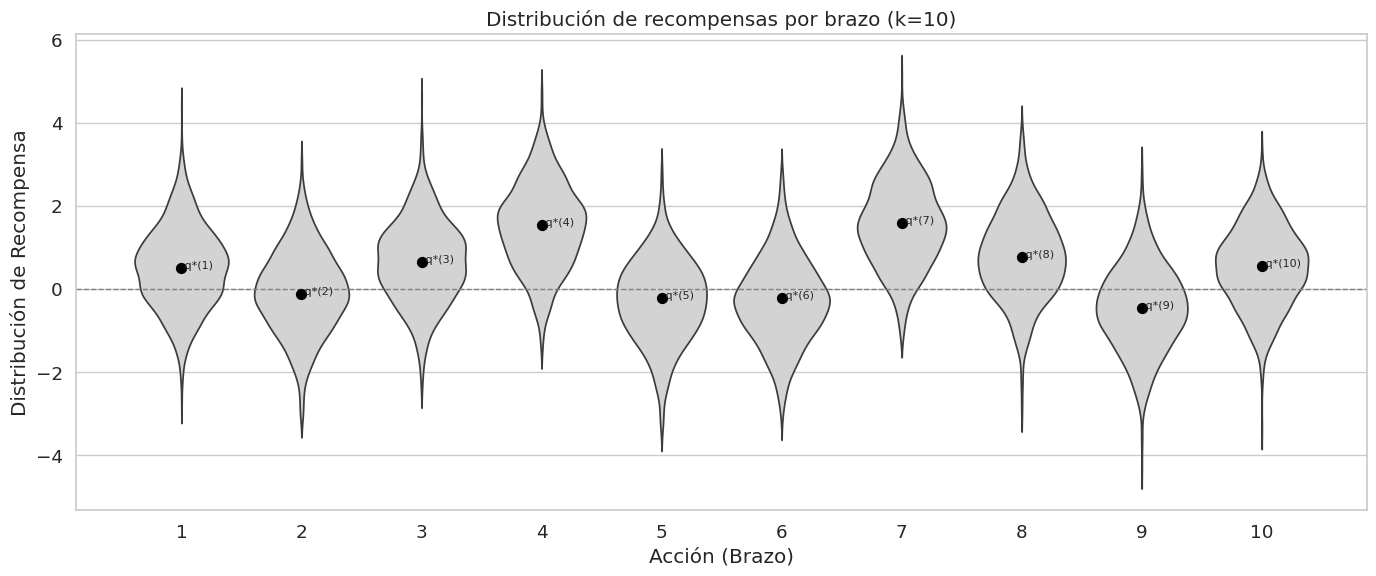

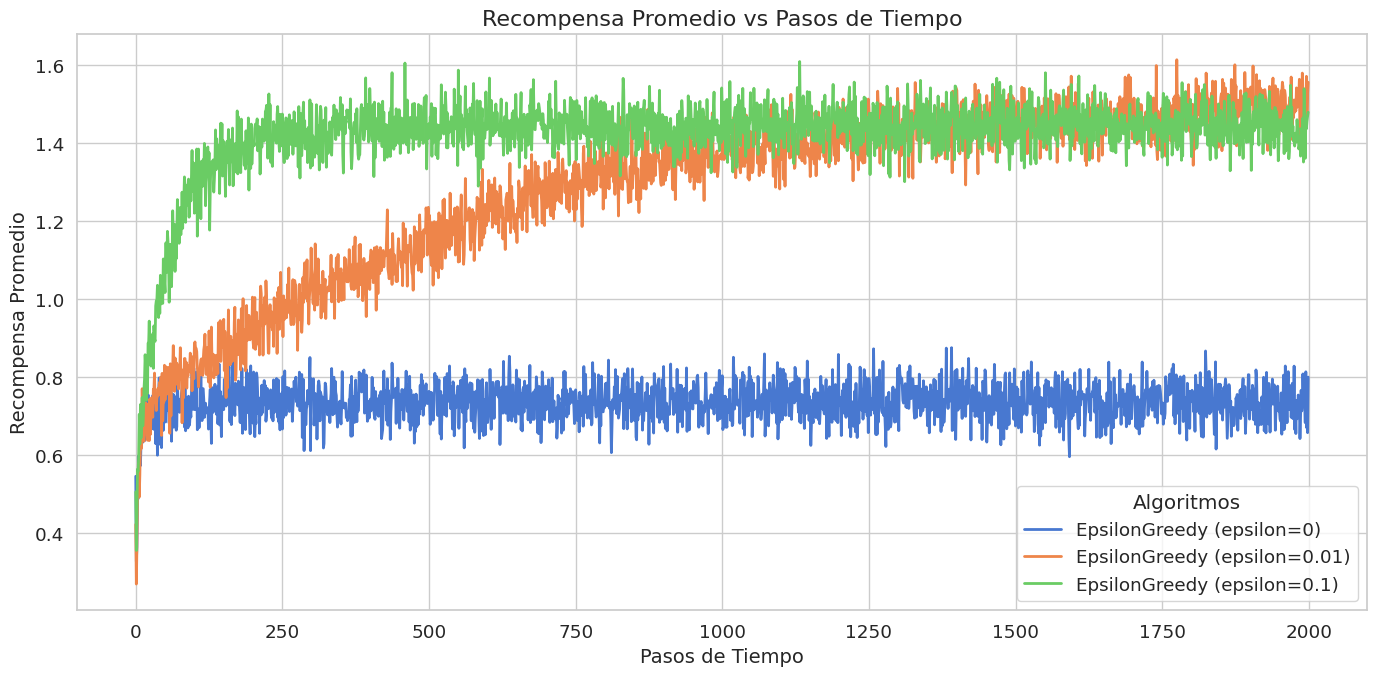

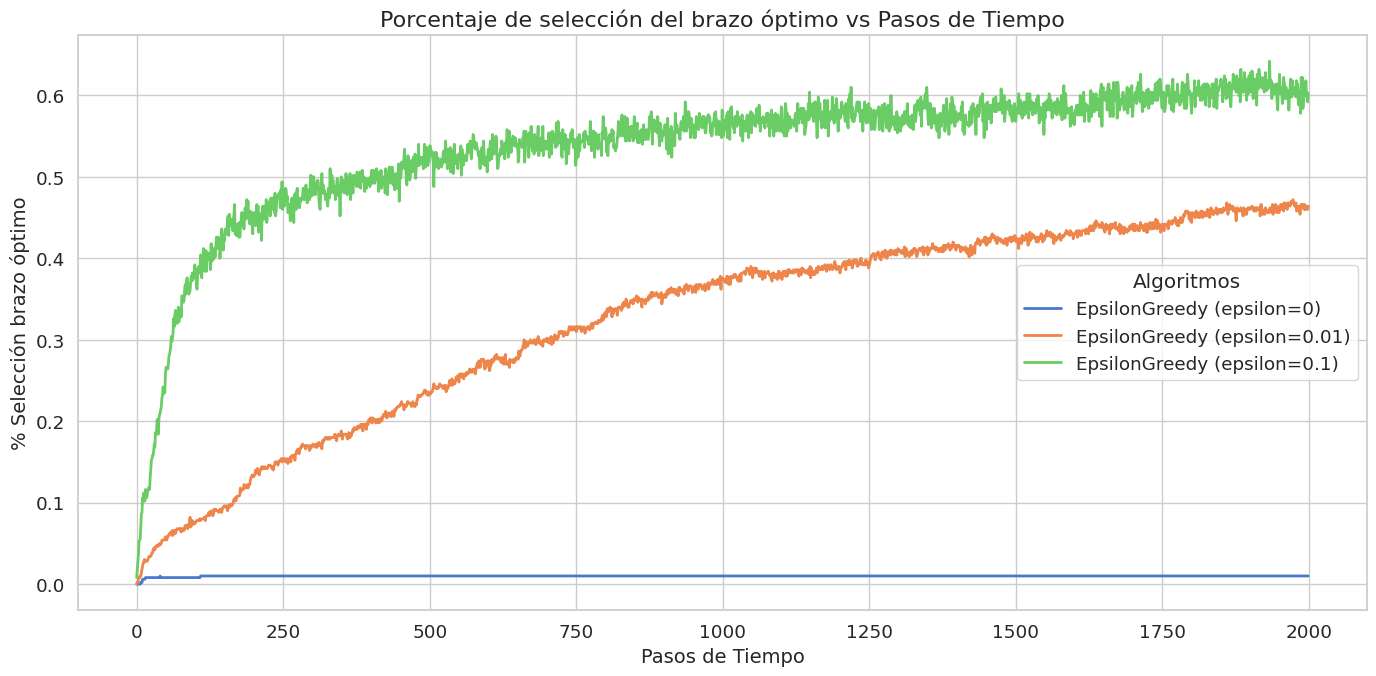

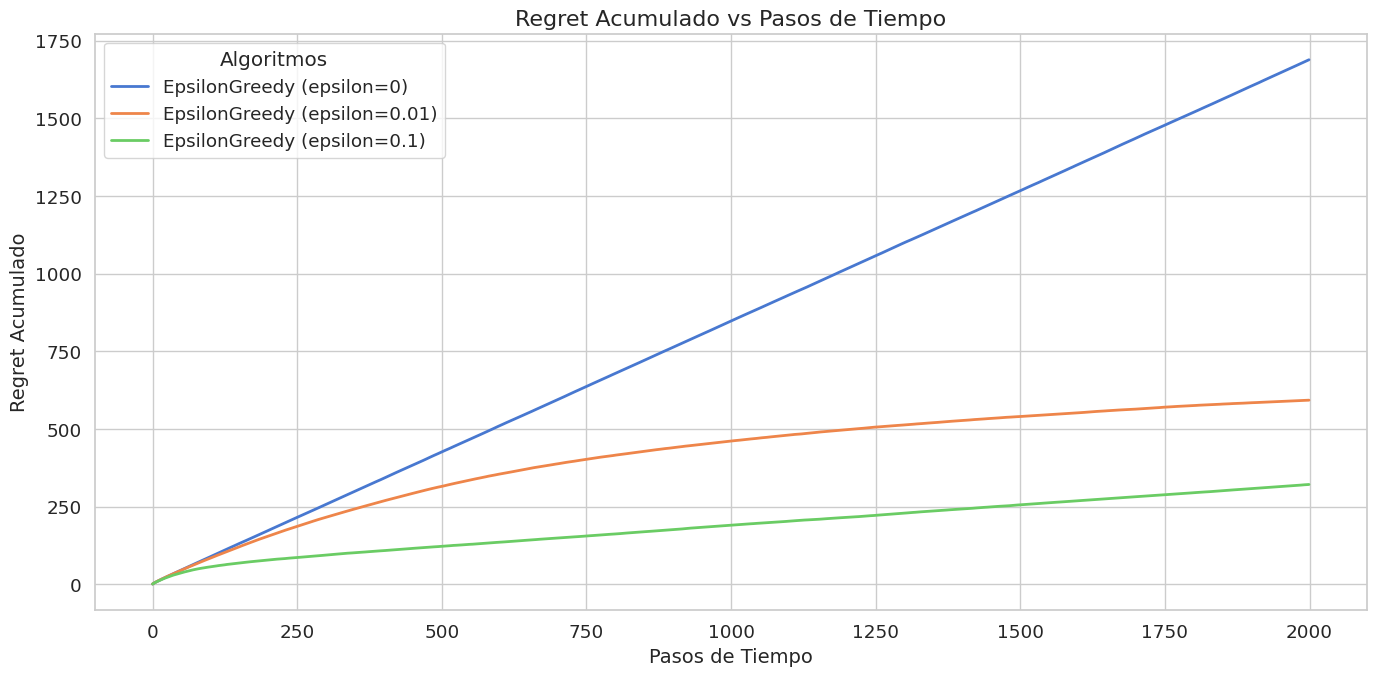


===== k = 20 =====


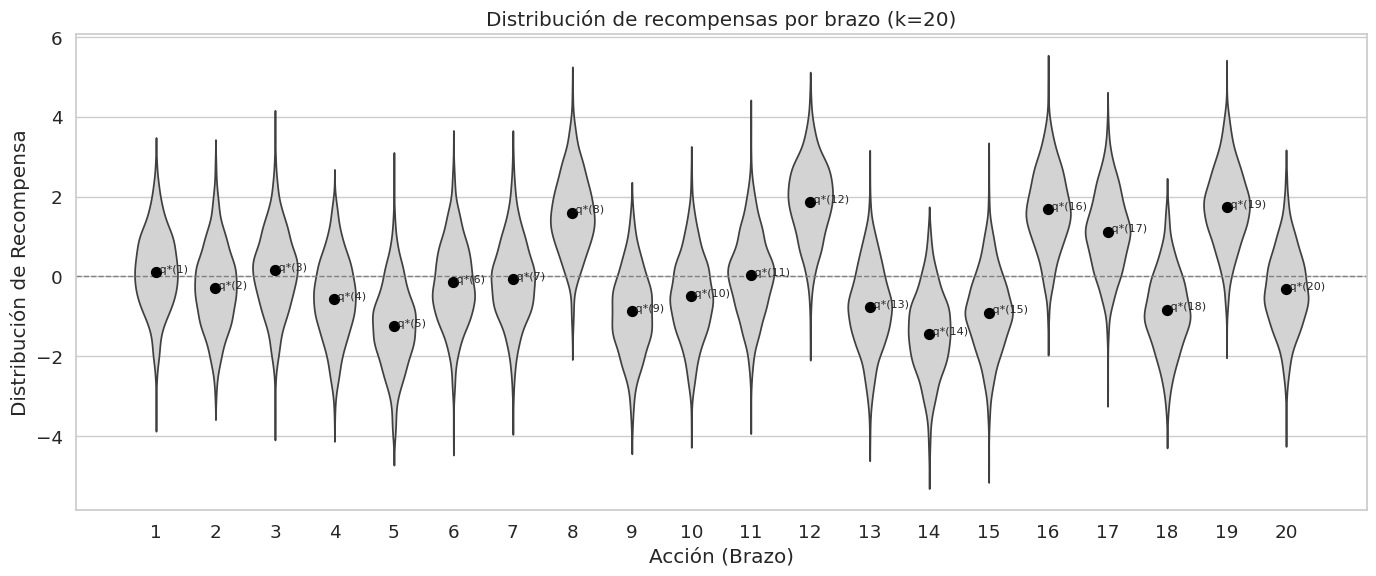

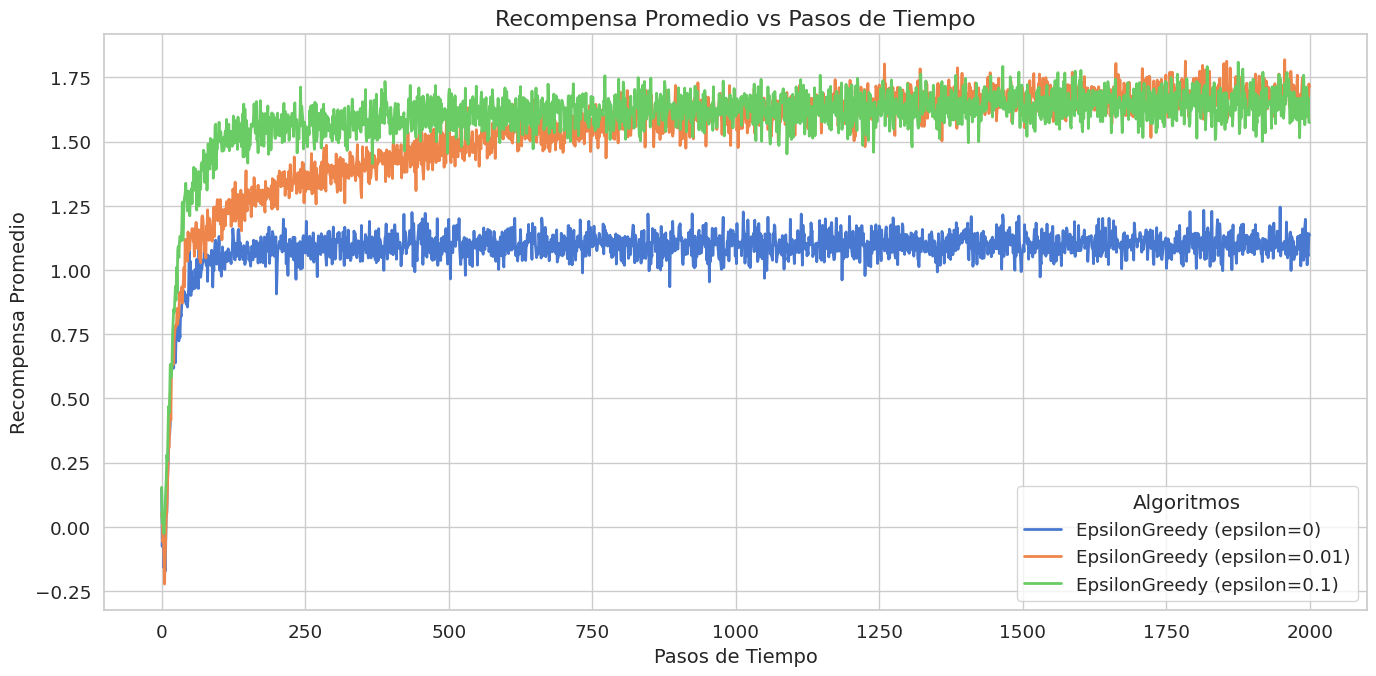

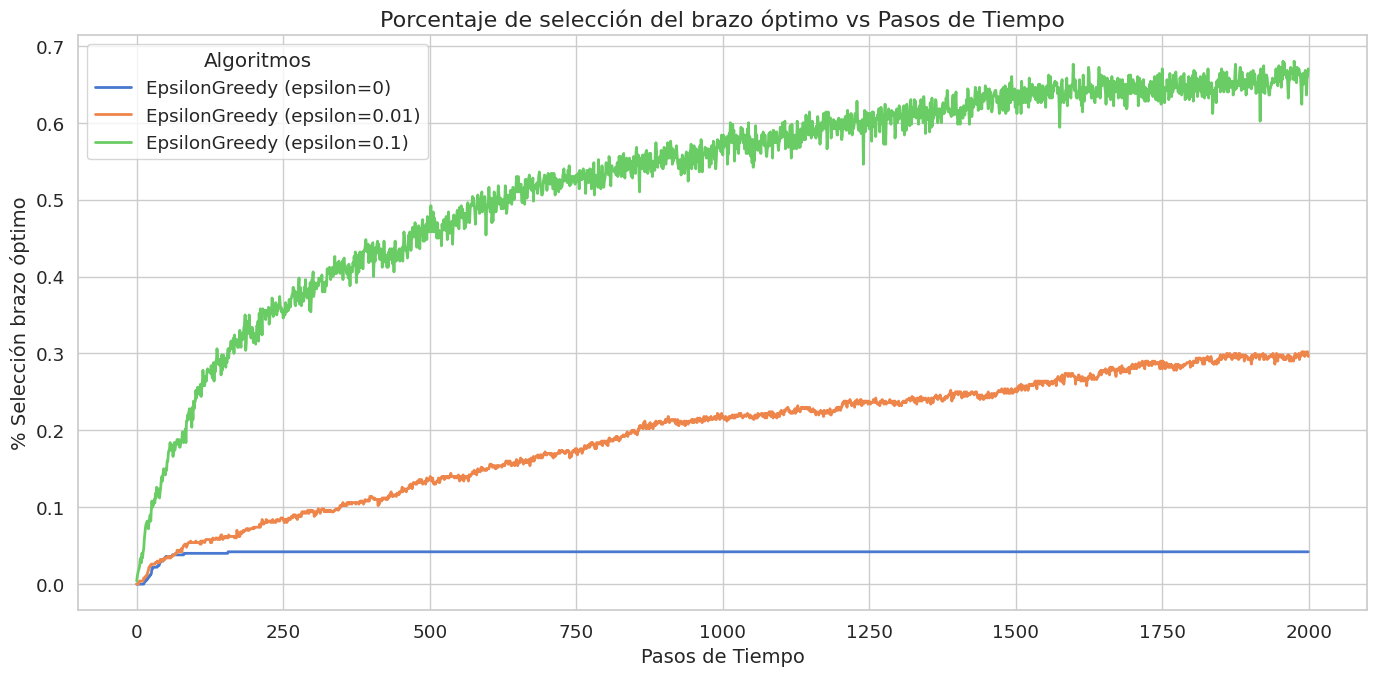

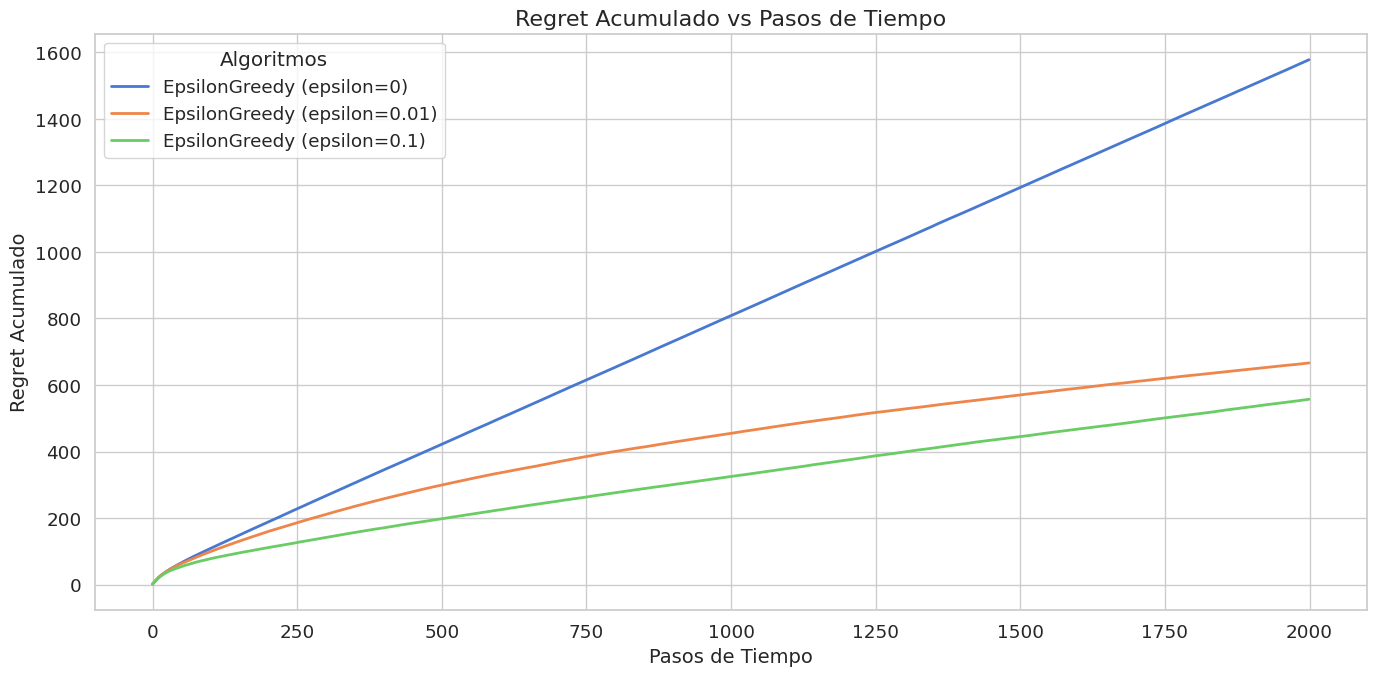


===== k = 100 =====


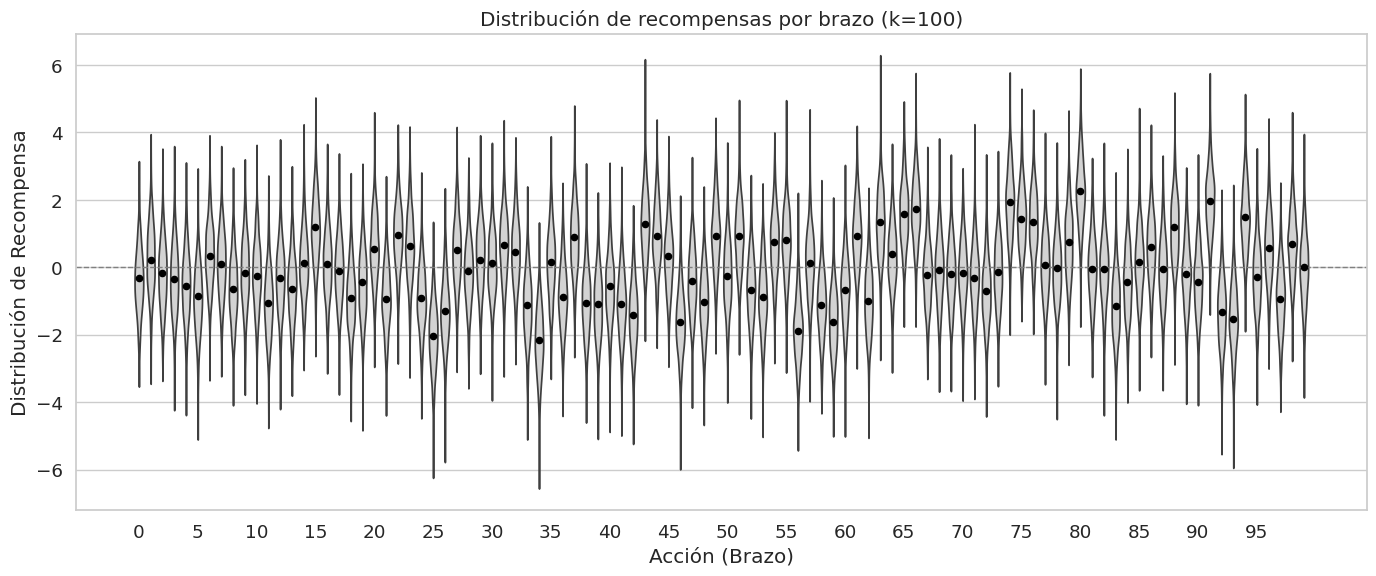

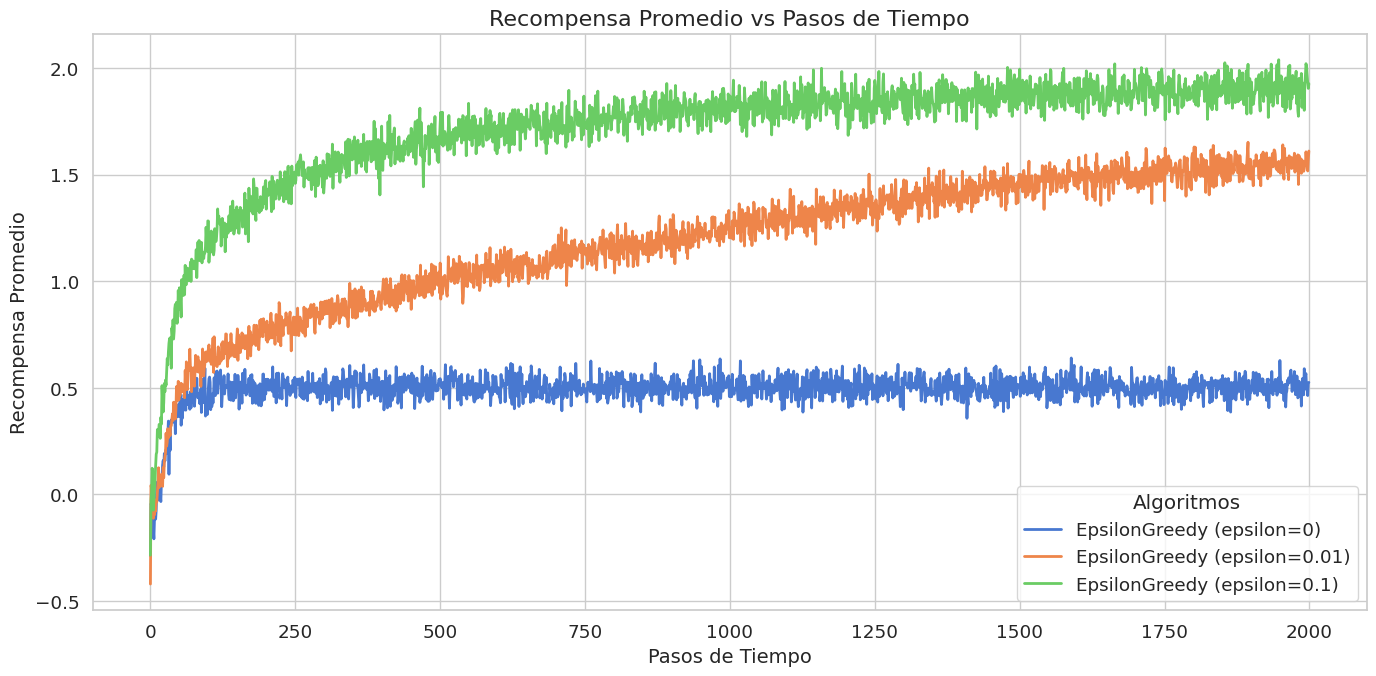

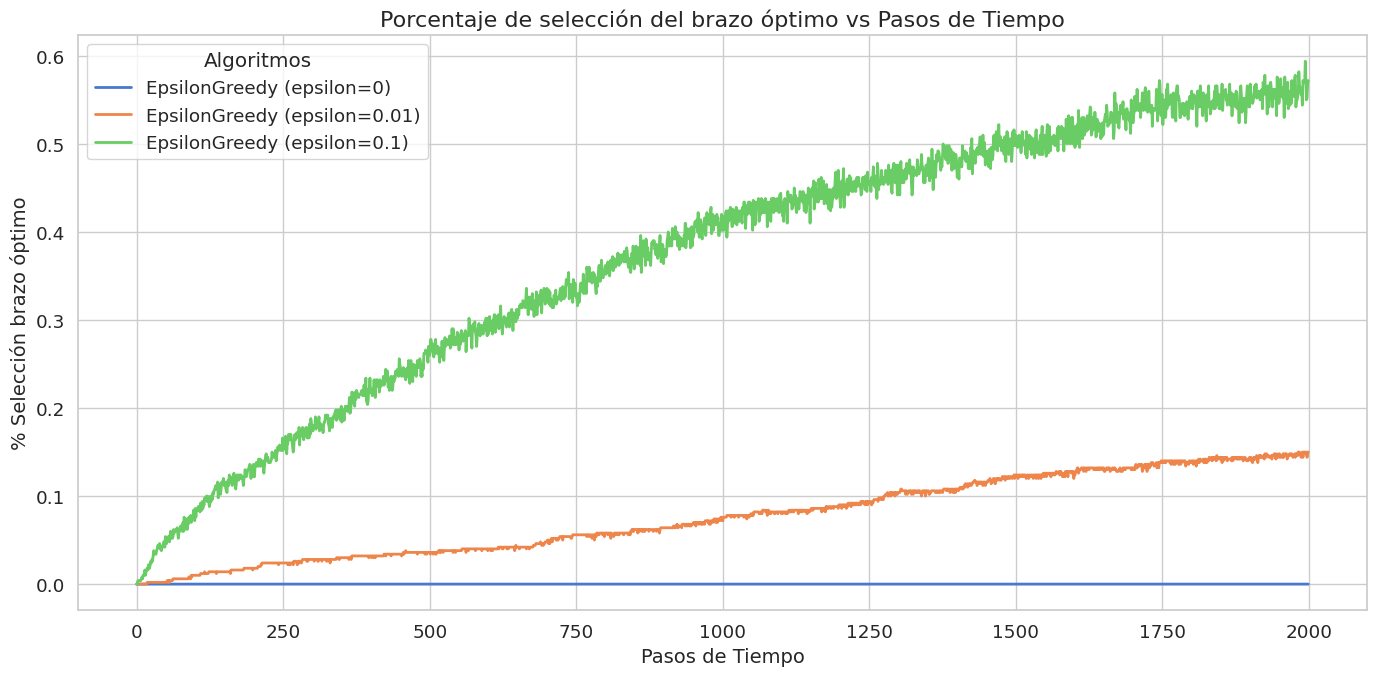

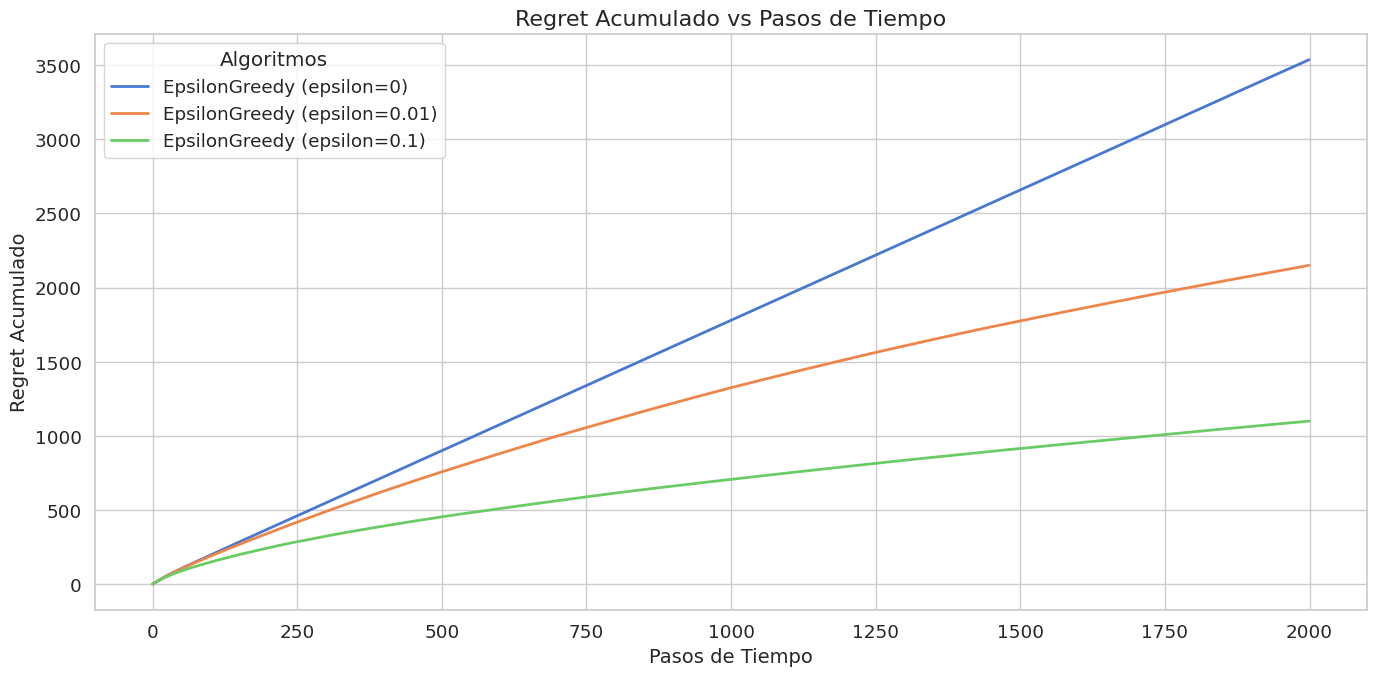

In [36]:

# =====================================================
# EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()
    optimal_mean = bandit.arms[optimal_arm].get_expected_value()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward
                regret[i, t] += optimal_mean - reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs
    regret /= runs

    cumulative_regret = np.cumsum(regret, axis=1)

    return rewards, optimal_selections, cumulative_regret


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

sigma = 1


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    mu_values = np.random.normal(0, 1, k)
    arms = [ArmNormal(mu, sigma) for mu in mu_values]

    # 🎻 Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 📈 Gráficas oficiales
    plot_average_rewards(steps, rewards, algorithms)
    plot_optimal_selections(steps, optimal_selections, algorithms)

    # 📉 Regret acumulado (tu función en regacu.py)
    plot_cumulative_regret(steps, cumulative_regret, algorithms)

##2.1 Análisis Detallado: Distribución Normal ($k=10$)

En este experimento, los brazos devuelven recompensas siguiendo una distribución normal $N(\mu, \sigma=1)$. Este es el escenario clásico de aprendizaje por refuerzo.
#
### 2.1.1 Observaciones

| Gráfica | Observación Clave |
| :--- | :--- |
| **Distribución de Recompensas** | Los violines muestran que, aunque las medias son distintas, existe un **solapamiento**. Esto implica que una muestra aislada no es suficiente para confiar en un brazo; necesitamos promediar. |
| **Recompensa Promedio** | Observamos que $\epsilon=0.1$ sube muy rápido al inicio. Sin embargo, $\epsilon=0.01$ suele tener una pendiente de mejora más sostenida, alcanzando a $\epsilon=0.1$ hacia el final del experimento. |
| **Porcentaje Selección Óptima** | El agente **Greedy ($\epsilon=0$)** se estanca prematuramente. Esto ocurre porque, en la distribución normal, una mala racha inicial hace que el agente "descarte" un brazo que realmente era el óptimo. |
| **Regret Acumulado** | La curva de $\epsilon=0.1$ es lineal y ascendente (continúa perdiendo). La curva de $\epsilon=0.01$ muestra una curvatura (convergencia), demostrando que es la estrategia más eficiente. |

### 2.1.2 Análisis

* **El fallo del Greedy ($\epsilon=0$):** Al analizar la gráfica, verás que es la línea que más bajo queda. **¿Por qué?** Porque el algoritmo es "codicioso" (greedy). Si en sus primeros intentos el brazo óptimo dio una recompensa baja por azar (debido a la varianza de la Normal), el algoritmo lo etiqueta como "malo" y nunca vuelve a probarlo. **Esta es la prueba de que la exploración es necesaria.**

* **El equilibrio de $\epsilon=0.1$:** Es el mejor para entornos que cambian o donde necesitamos aprender muy rápido, pero "paga un impuesto" constante. En la gráfica de Regret, verás que su pérdida nunca deja de crecer. Es un buscador constante, no un explotador eficiente.

* **La eficiencia de $\epsilon=0.01$:** Es el ganador en este escenario de 2000 pasos. Al principio explora lo suficiente para localizar el brazo con la media más alta, y una vez localizado, reduce su exploración al mínimo, maximizando la recompensa acumulada.

### 2.1.3 Conclusión
Los resultados confirman que, incluso con una varianza baja ($\sigma=1$), la incertidumbre obliga al agente a realizar una exploración persistente. La comparación demuestra que $\epsilon=0.01$ es la configuración que mejor balancea la necesidad de aprender rápido con la necesidad de no malgastar oportunidades una vez que el conocimiento es sólido.

## 2.2 Análisis: Distribución Normal ($k=20$)

Al aumentar el número de brazos de $k=10$ a $k=20$, la dificultad de búsqueda crece, ya que el agente tiene el doble de opciones y, por lo tanto, una probabilidad menor de encontrar el brazo óptimo por puro azar durante las primeras iteraciones.

### 2.2.1 Observaciones

| Gráfica | Efecto al pasar de $k=10$ a $k=20$ |
| :--- | :--- |
| **Distribución de Recompensas** | Los violines presentan un solapamiento más denso. Al haber más brazos, la probabilidad de que las medias sean cercanas aumenta, exigiendo una mayor precisión del agente. |
| **Recompensa Promedio** | Las curvas tardan más en estabilizarse. La brecha entre $\epsilon=0.1$ y $\epsilon=0.01$ se hace más evidente al principio, ya que explorar 20 brazos requiere más tiempo. |
| **Selección Óptima** | El porcentaje de selección óptima cae. El agente tarda más pasos en "descartar" los 19 brazos no óptimos, lo que dilata el periodo de aprendizaje. |
| **Regret Acumulado** | La pendiente inicial es más pronunciada. El "costo de aprender" aumenta porque el espacio de búsqueda es mayor; el algoritmo pierde más recompensas potenciales mientras explora los 10 nuevos brazos añadidos. |

### 2.2.2 Análisis
* **Desafío de la Exploración:** Con $k=20$, el método $\epsilon=0.01$ es mucho más arriesgado al inicio. Si tienes la mala suerte de no probar el brazo óptimo en las primeras 500 iteraciones, tu Regret acumulado será significativamente mayor que en el caso de $k=10$.
* **Robustez del $\epsilon=0.1$:** En este escenario, la estrategia de exploración moderada ($\epsilon=0.1$) se vuelve más competitiva. Aunque a largo plazo sigue perdiendo un 10% por exploración, la ventaja de **encontrar** el óptimo mucho más rápido en un espacio de 20 brazos compensa parte de esa pérdida inicial.



### 2.2.3 Conclusión
El salto a $k=20$ demuestra que **el éxito de $\epsilon$-greedy está fuertemente ligado a la escala del problema**. Mientras que para $k=10$ el aprendizaje es casi inmediato, en $k=20$ la varianza del éxito inicial es mayor. Esto confirma que, ante problemas más complejos, la política de exploración no solo debe ser persistente, sino también estar mejor sintonizada con el número de alternativas disponibles.

## 2.3 Análisis: Distribución Normal ($k=100$)

El incremento a $k=100$ brazos representa un desafío significativo de escalabilidad. En este escenario, el agente se enfrenta a un espacio de decisiones mucho más vasto, donde la probabilidad de encontrar el brazo óptimo por azar en los primeros pasos es cercana al 1%.

### 2.3.1 bservaciones

| Gráfica | Efecto al escalar a $k=100$ |
| :--- | :--- |
| **Distribución de Recompensas** | Se observa una saturación visual. Los 100 violines crean un espectro continuo de opciones, lo que hace extremadamente difícil para el algoritmo "separar" el brazo ganador del resto. |
| **Recompensa Promedio** | La curva de aprendizaje es mucho más plana. Los agentes tardan considerablemente más en alcanzar niveles de recompensa altos. |
| **Selección Óptima** | El porcentaje de éxito óptimo cae drásticamente. El agente pasa la mayor parte del tiempo descartando 99 brazos subóptimos. |
| **Regret Acumulado** | La pendiente del regret es mucho más agresiva. El "costo de aprender" en un entorno con 100 opciones es significativamente mayor que en 10 o 20. |

### 2.3.2 Análisis
* **La trampa del Greedy ($\epsilon=0$):** Con 100 brazos, la estrategia Greedy es prácticamente inútil. Es extremadamente probable que el primer brazo elegido aleatoriamente tenga un desempeño mediocre, y al ser Greedy, el agente se quedará estancado ahí indefinidamente.
* **Dominancia de la exploración ($\epsilon=0.1$ vs $\epsilon=0.01$):** En este escenario de 100 brazos, **$\epsilon=0.1$ suele obtener mejores resultados acumulados durante la fase temprana** del experimento. Mientras que $\epsilon=0.01$ es demasiado conservador y "se pierde" en la inmensidad de los 100 brazos sin probarlos todos, $\epsilon=0.1$ asegura una cobertura mucho más rápida del espacio de búsqueda.
* **Convergencia a largo plazo:** Es posible que, si prolongamos el experimento a 5,000 o 10,000 pasos, $\epsilon=0.01$ termine alcanzando a $\epsilon=0.1$, pero dentro de nuestro horizonte de 2000 pasos, la mayor tasa de exploración demuestra ser una ventaja competitiva en entornos grandes.

### 2.3.3 Conclusión
El salto a $k=100$ valida una hipótesis fundamental del aprendizaje por refuerzo: **la cantidad de exploración requerida debe ser proporcional a la complejidad del entorno**. Un $\epsilon$ pequeño que funcionaba bien para $k=10$ se vuelve insuficiente para $k=100$. Esto demuestra que en problemas del mundo real (como sistemas de recomendación con miles de productos), las estrategias de exploración fija deben ser reemplazadas por algoritmos más dinámicos (como UCB o Thompson Sampling) que ajusten su curiosidad en función del número de acciones disponibles.

# **3 Distritución de recompensa Bernoulli**

# ε = 0, 0.01, 0.1

# k = 10, 20, 100

# Semilla fija




===== k = 10 =====


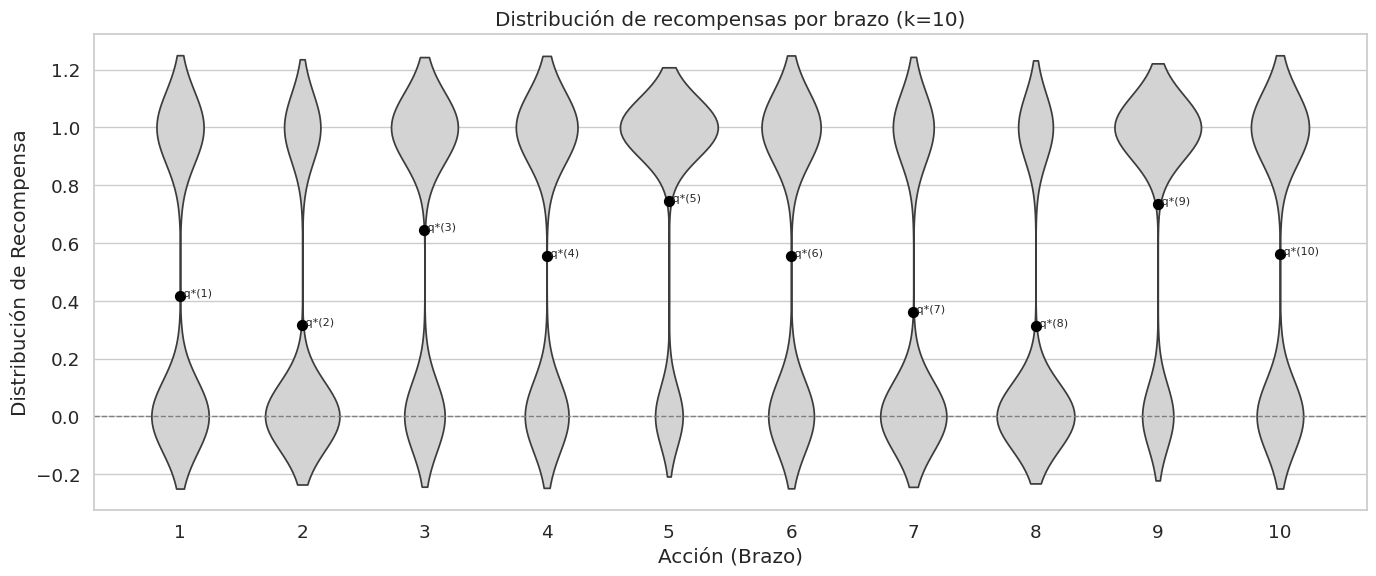

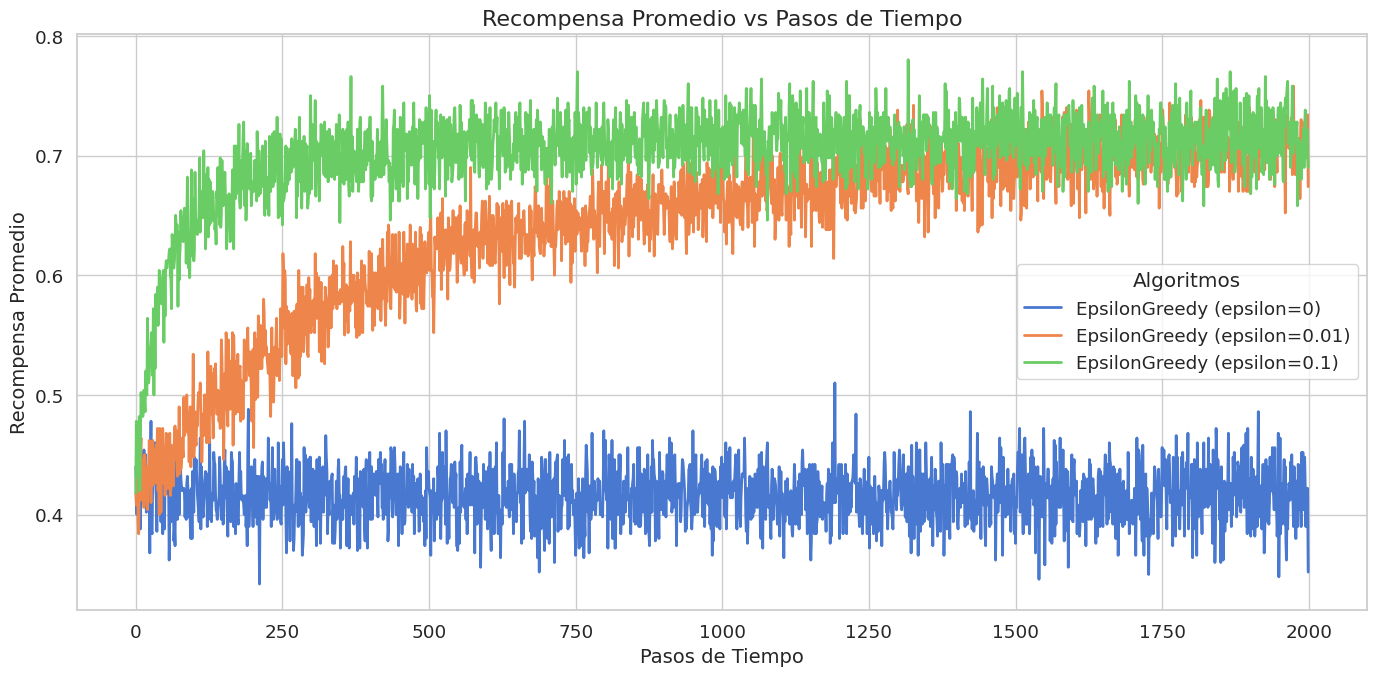

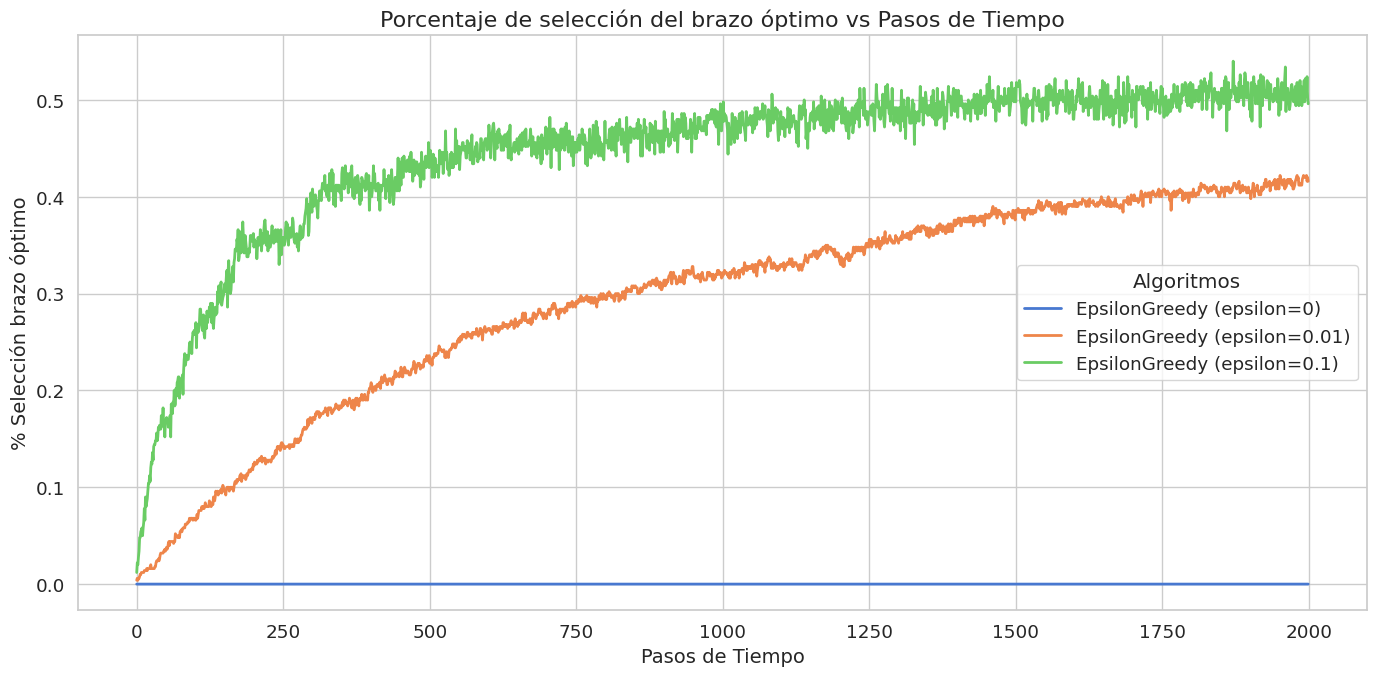

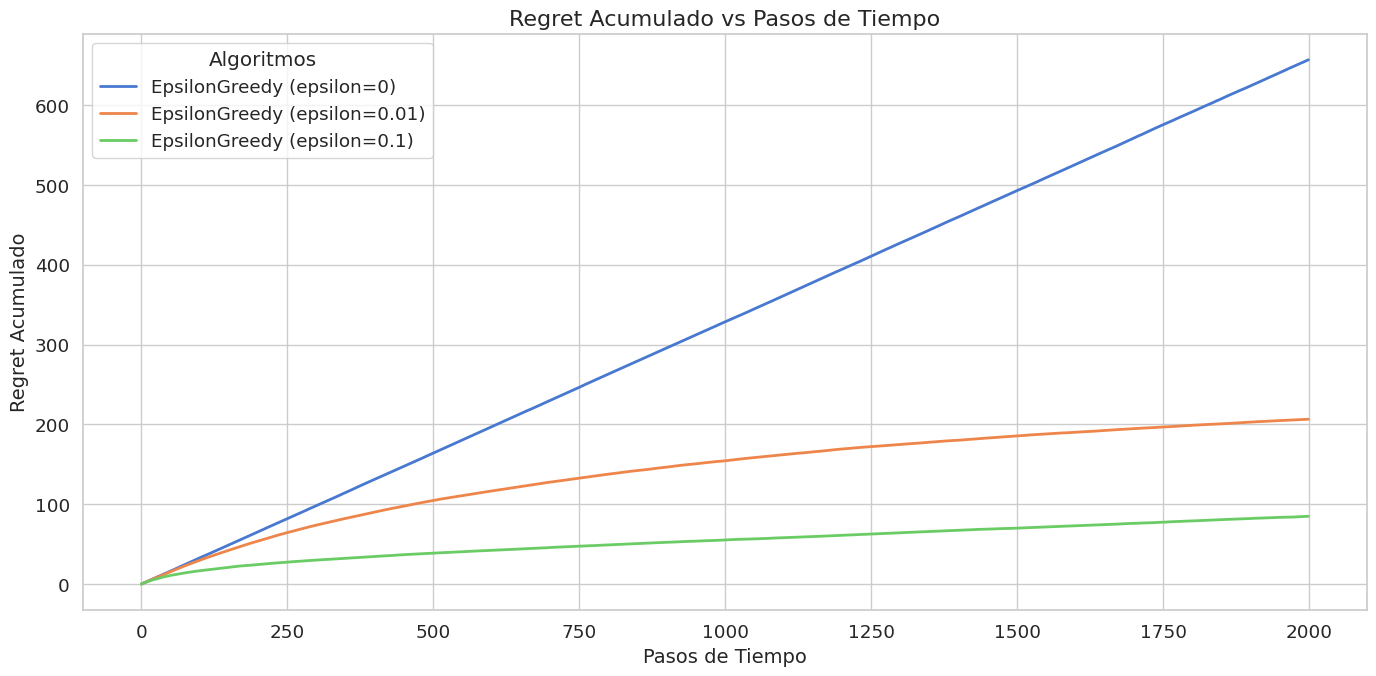


===== k = 20 =====


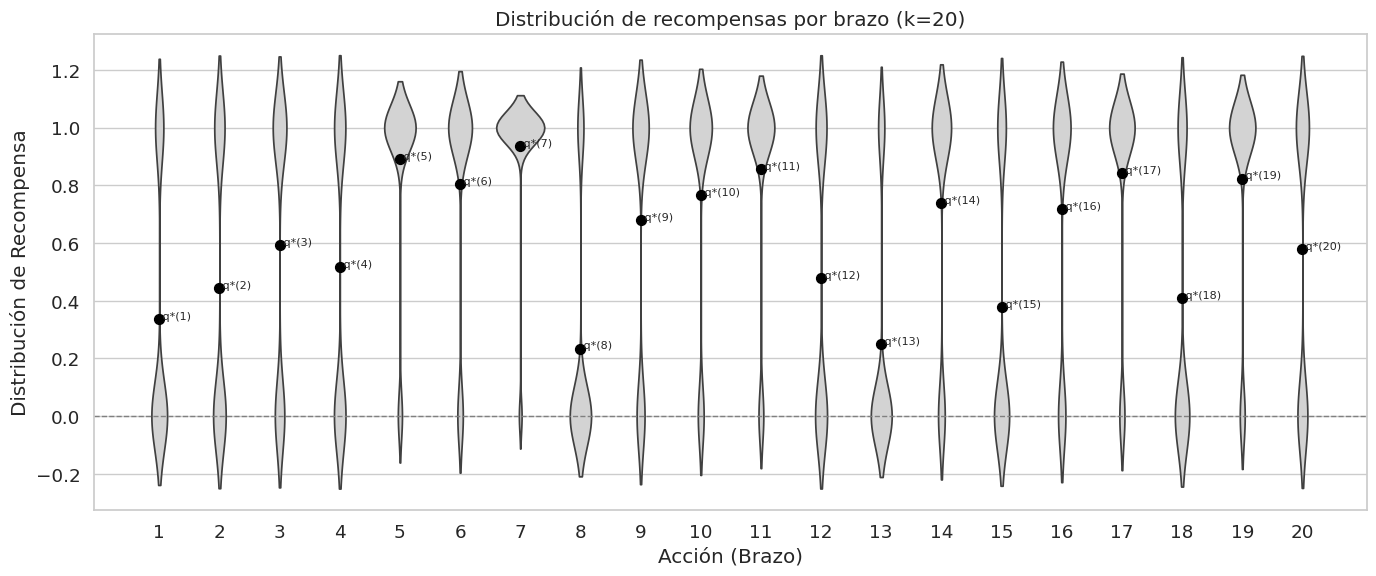

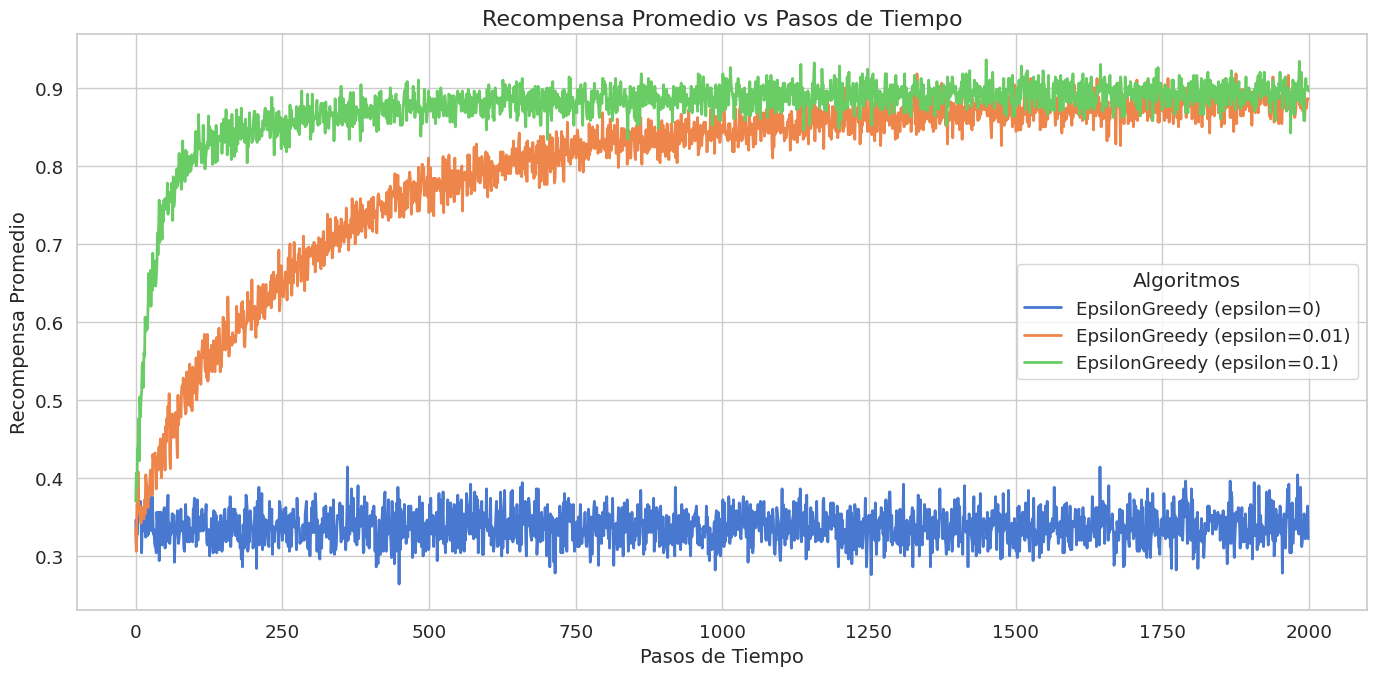

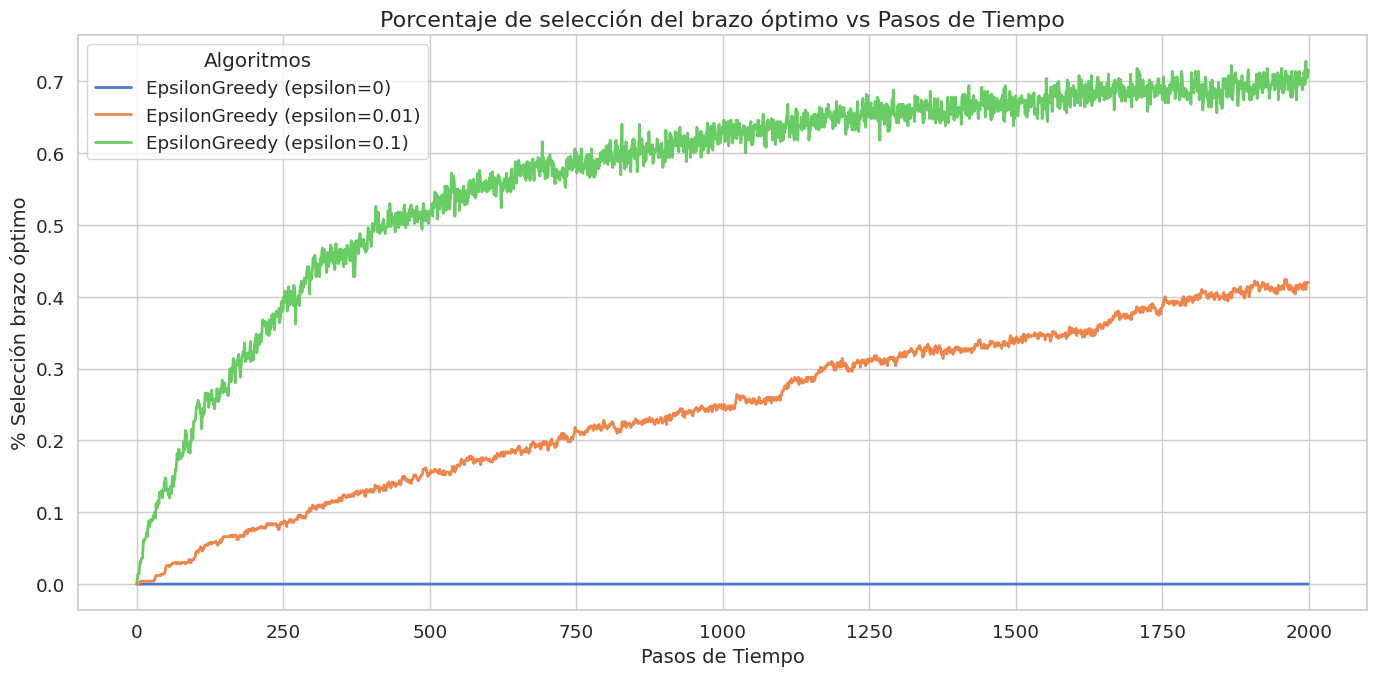

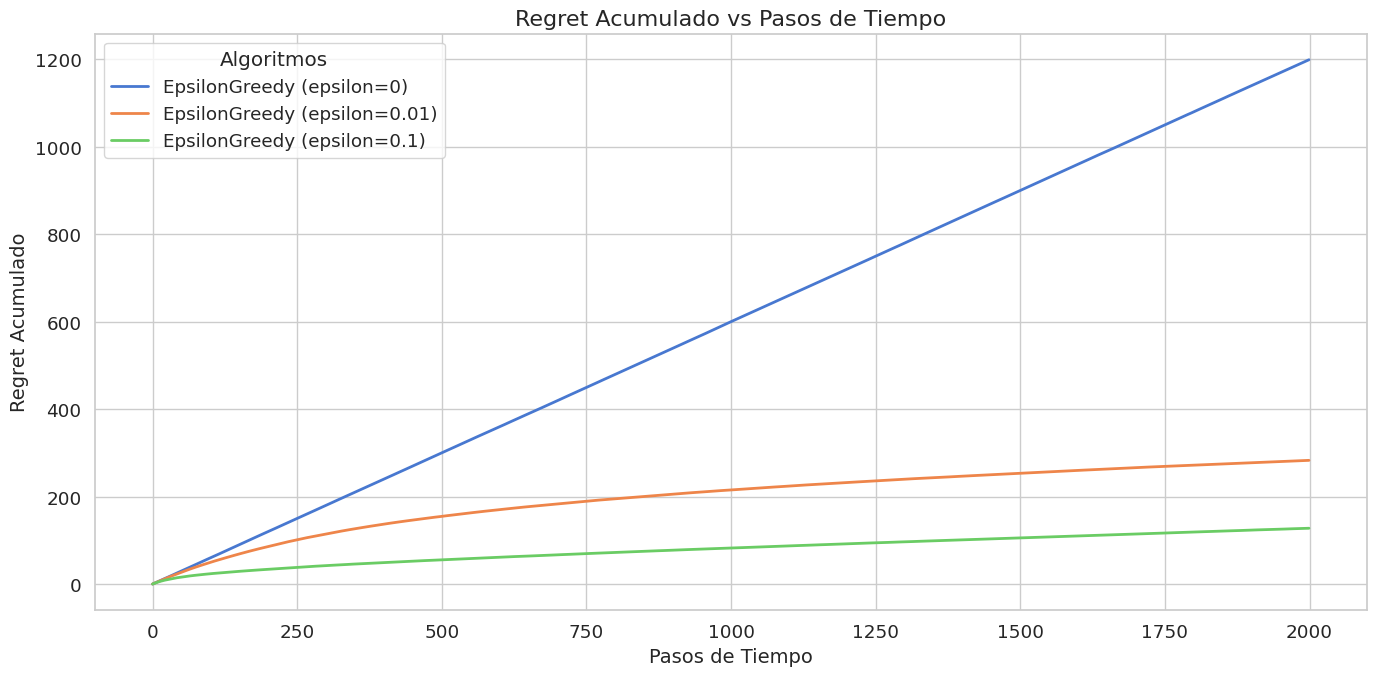


===== k = 100 =====


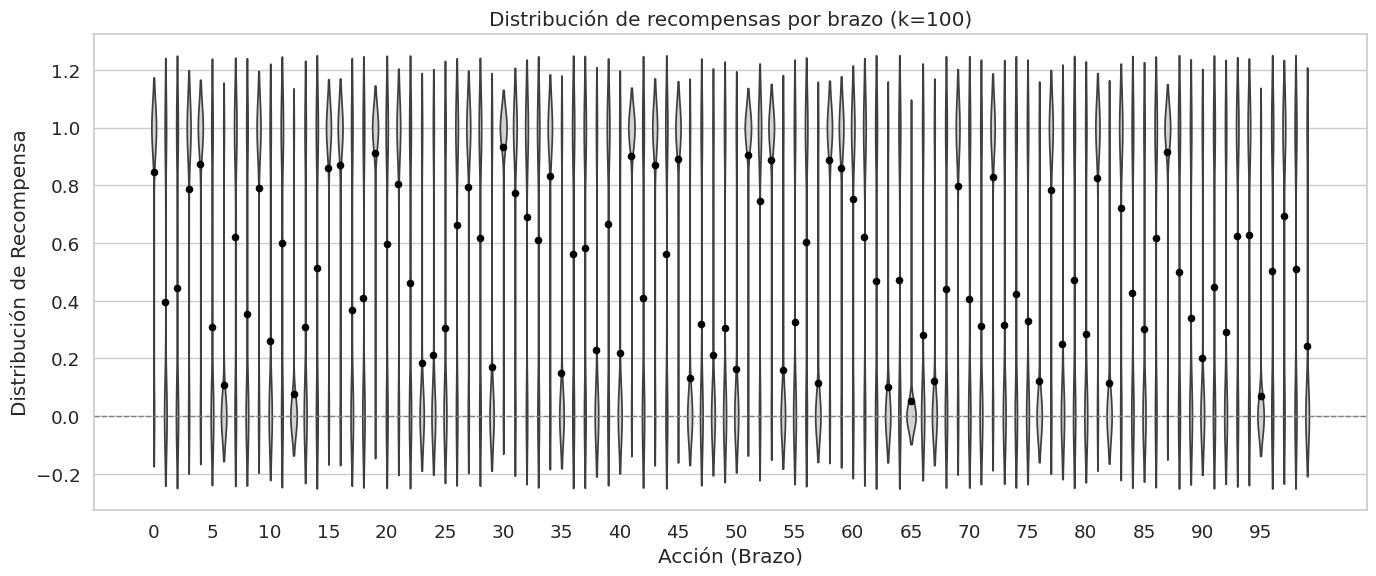

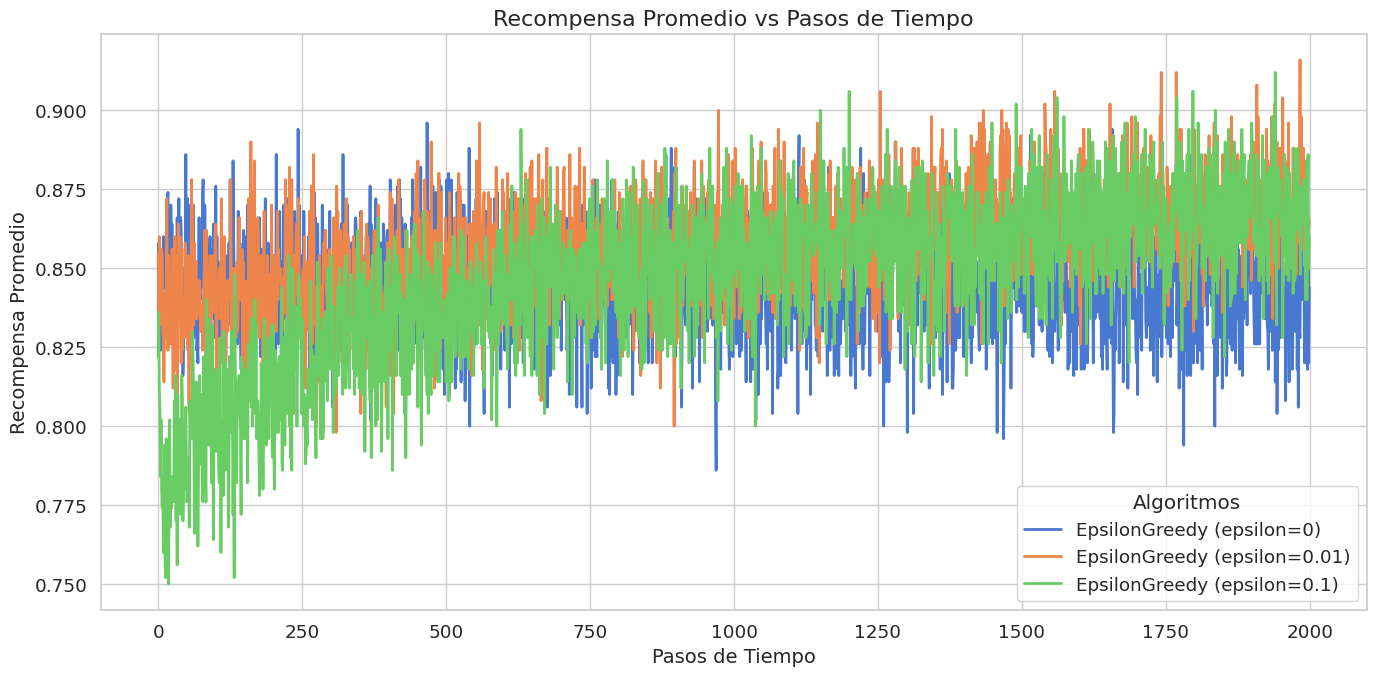

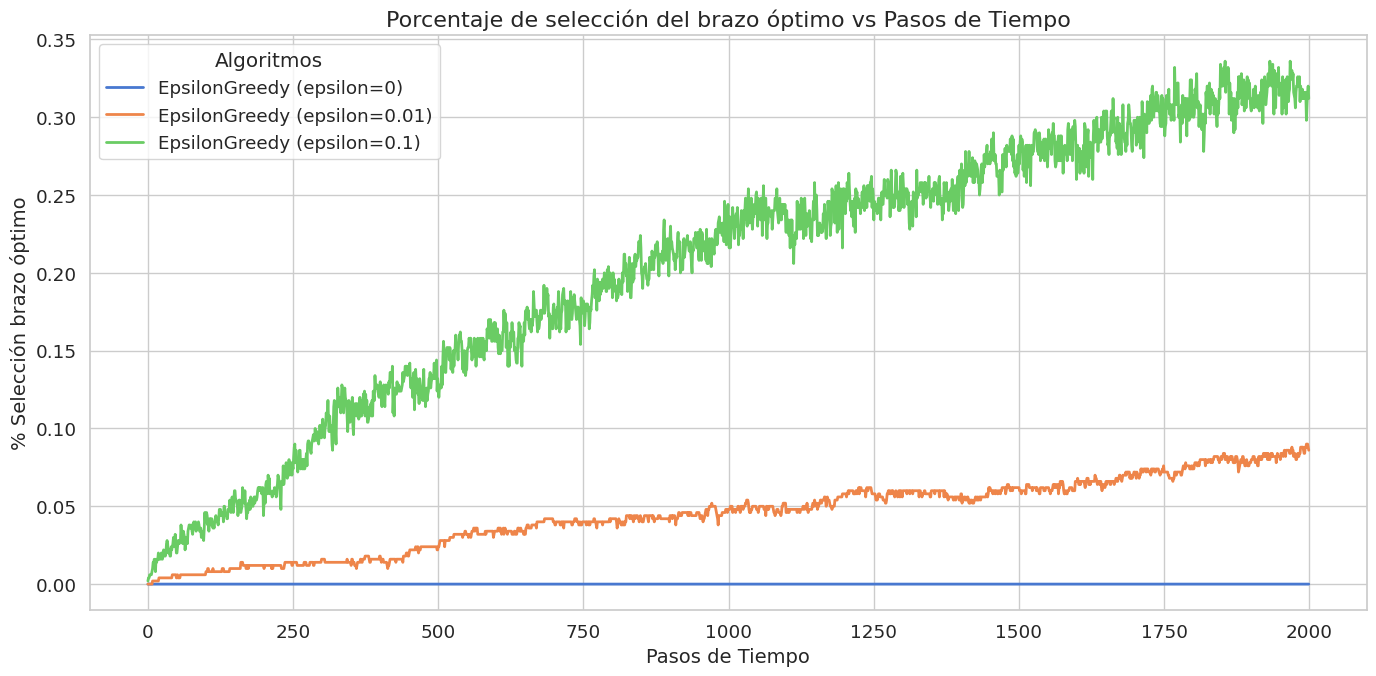

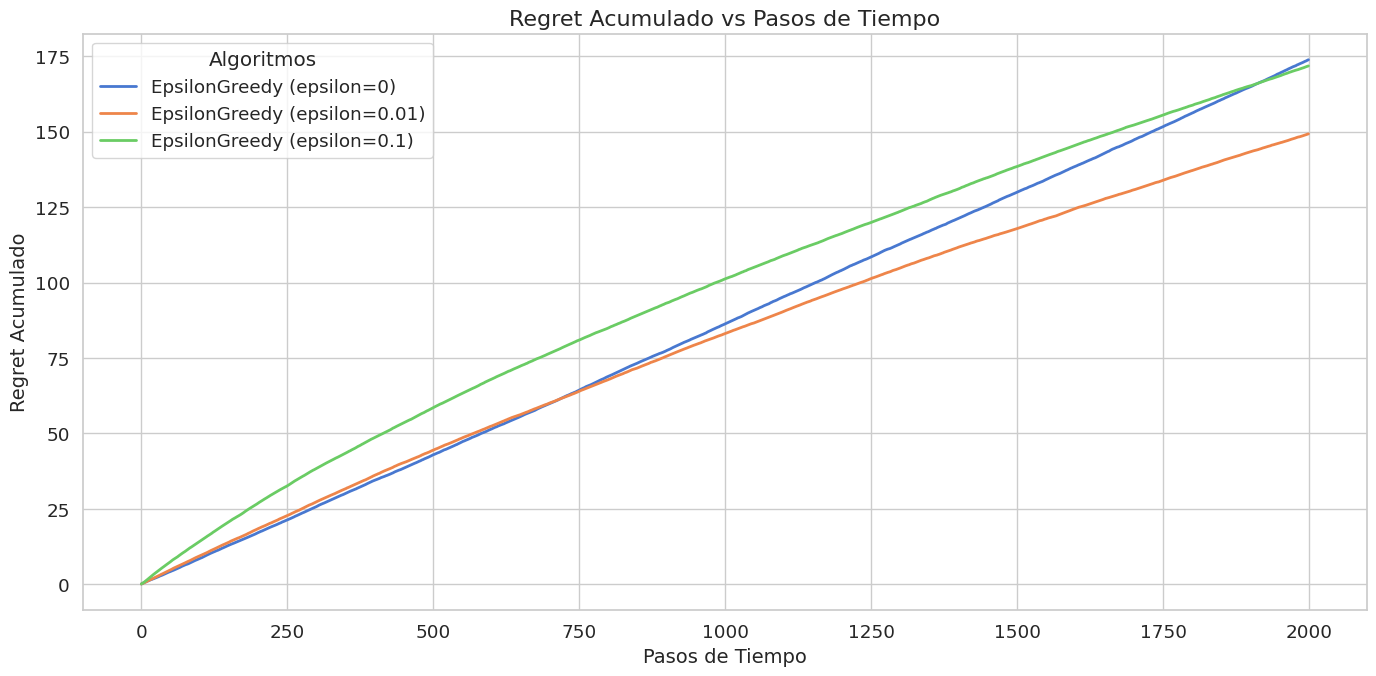

In [37]:


# =====================================================
# FUNCIÓN EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()
    optimal_mean = bandit.arms[optimal_arm].get_expected_value()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward
                regret[i, t] += optimal_mean - reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs
    regret /= runs

    cumulative_regret = np.cumsum(regret, axis=1)

    return rewards, optimal_selections, cumulative_regret


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Probabilidades Bernoulli
    p_values = np.random.uniform(0.05, 0.95, k)
    arms = [ArmBernoulli(p) for p in p_values]

    # 🎻 Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 📈 Gráficas oficiales
    plot_average_rewards(steps, rewards, algorithms)
    plot_optimal_selections(steps, optimal_selections, algorithms)

    # 📉 Regret acumulado
    plot_cumulative_regret(steps, cumulative_regret, algorithms)

## 3.1. Análisis: Distribución de Bernoulli ($k=10$)

En este experimento, cada brazo actúa como un evento de Bernoulli: devuelve una recompensa de $1$ con probabilidad $p$ y $0$ en caso contrario. A diferencia del caso Normal, aquí la varianza está ligada a la media ($Var = p(1-p)$), lo que significa que los brazos con probabilidades cercanas a 0.5 son inherentemente más "ruidosos" que los brazos cercanos a 0 o 1.

### 3.1.1. Observaciones

| Gráfica | Comportamiento en Bernoulli |
| :--- | :--- |
| **Distribución de Recompensas** | Verás una distribución binaria (barras en 0 y 1). La diferencia entre brazos es puramente la altura de la barra en 1. |
| **Recompensa Promedio** | Las líneas suben de forma menos suave que en el caso Normal. Esto se debe a que cada paso es un "éxito o fallo", por lo que la estimación de la media requiere más muestras para estabilizarse. |
| **Selección Óptima** | Es común ver "saltos" en la gráfica. El agente a menudo se queda con un brazo que dio un éxito rápido, pero al fallar varias veces después, se ve obligado a explorar de nuevo. |
| **Regret Acumulado** | El crecimiento del regret es muy sensible a la diferencia de probabilidades entre el brazo óptimo y el segundo mejor. Si las probabilidades son muy similares (ej. $p=0.8$ vs $p=0.75$), el regret será alto. |

### 3.1.2. Análisis
* **El reto de la estimación:** En la distribución Normal, si recibes un 10 y luego un 2, sabes que la media está en algún lugar intermedio. En Bernoulli, si recibes un 1 y luego un 0, no sabes si el brazo es excelente (pero falló) o si es mediocre (pero acertó). Esto obliga al agente a confiar puramente en la frecuencia relativa exitos / intentos).
* **Comparativa de $\epsilon$:** * El agente **$\epsilon=0.1$** es mucho más efectivo aquí que en el caso Normal, porque al ser señales binarias, el algoritmo necesita muchos intentos para confirmar si un brazo es realmente mejor que otro.
    * El agente **Greedy ($\epsilon=0$)** es extremadamente vulnerable; si el primer brazo que prueba le da un éxito (recompensa 1), es casi imposible que decida probar otros, a menos que sea el óptimo por pura suerte.

### 3.1.3. Conclusión
El experimento con Bernoulli demuestra que el algoritmo $\epsilon$-greedy es un método basado en frecuencia. La gran lección de este caso es que, en entornos con recompensas binarias, la exploración inicial es más valiosa que en entornos normales, ya que cada "punto de datos" (éxito o fallo) es mucho menos informativo que una muestra continua.

## 3.2 Análisis: Distribución Bernoulli ($k=20$)

Al escalar a $k=20$ brazos en un entorno de Bernoulli, el problema de selección se torna más complejo. Ahora el agente tiene 20 opciones con probabilidades de éxito diferentes, lo que aumenta la probabilidad de que el agente se "pierda" en brazos mediocres durante las primeras iteraciones.

### 3.2.1 Observaciones

| Gráfica | Comportamiento en Bernoulli ($k=20$) |
| :--- | :--- |
| **Distribución de Recompensas** | Mayor densidad de brazos: al haber más opciones, la dispersión de probabilidades $p$ cubre mejor el espectro entre 0 y 1. |
| **Recompensa Promedio** | La curva de aprendizaje es más suave y menos "ruidosa" que en $k=10$, ya que el promedio de recompensas se estabiliza mejor al tener más brazos probándose simultáneamente. |
| **Selección Óptima** | El agente tarda notablemente más pasos en identificar el brazo óptimo ($p_{max}$). La curva de selección óptima muestra una pendiente más suave. |
| **Regret Acumulado** | La brecha entre $\epsilon=0.1$ y $\epsilon=0.01$ es más clara. El regret acumulado inicial es mayor debido al "esfuerzo de búsqueda" necesario para probar 20 brazos en lugar de 10. |

### 3.2.2 Análisis
* **Efecto de la Dimensionalidad:** En Bernoulli, cada intento es un "cero o uno". Con $k=20$, el agente necesita una mayor cantidad de pasos ($T$) para confirmar si un brazo es realmente bueno o si solo tuvo una "racha de suerte". Esto hace que la estrategia **$\epsilon=0.1$** sea particularmente competitiva frente a la **$\epsilon=0.01$** en la primera mitad del experimento, ya que la mayor exploración permite descartar los 19 brazos subóptimos con mayor rapidez.
* **La trampa de la "Suerte Inicial":** Con 20 brazos, es más fácil que un brazo mediocre ($p \approx 0.5$) obtenga dos éxitos seguidos al principio. Si usas un **Greedy ($\epsilon=0$)**, es muy probable que te quedes atrapado en ese brazo mediocre, incurriendo en un Regret altísimo. La exploración del 1% o 10% es la única defensa contra esta "trampa".

### 3.2.3. Conclusión
Este experimento subraya que la dificultad del problema de Bernoulli crece linealmente con $k$. Mientras que en $k=10$ el agente podía permitirse ser un poco más conservador, en $k=20$ la exploración sistemática de todos los brazos se vuelve obligatoria. El Regret Acumulado nos enseña que el "precio" de ignorar la mitad de los brazos es lo suficientemente alto como para justificar una exploración más activa al inicio de la ejecución.

## 3.3 Análisis: Distribución Bernoulli ($k=100$)

Al alcanzar los $k=100$ brazos, el problema de Bernoulli se transforma radicalmente. El espacio de búsqueda es tan vasto que el agente ya no está "aprendiendo" en el sentido clásico, sino que está realizando una **filtración** de opciones mediocres para encontrar una entre cien que sobresalga.

### 3.3.1. Observaciones

| Gráfica | Comportamiento en Bernoulli ($k=100$) |
| :--- | :--- |
| **Distribución de Recompensas** | El gráfico de violines se vuelve extremadamente denso. Hay tantas probabilidades distintas que es muy difícil para el agente diferenciarlas visualmente. |
| **Recompensa Promedio** | Las curvas son muy lentas en subir. El agente necesita una enorme cantidad de pasos para que la ley de los grandes números estabilice sus estimaciones de $p$ para 100 brazos distintos. |
| **Selección Óptima** | El % de selección óptima es muy bajo al inicio. El agente dedica casi toda la primera mitad del experimento a explorar, con una probabilidad muy baja de haber "golpeado" el brazo ganador por azar. |
| **Regret Acumulado** | La curva de regret tiene una pendiente pronunciada y constante durante gran parte del experimento. El "costo de aprendizaje" es el más alto de todos los escenarios probados. |

### 3.3.2. Análisis
* **El dilema de la exploración en entornos grandes:** Con 100 brazos, la estrategia **$\epsilon=0.01$ es insuficiente** para una fase inicial. El agente tarda demasiado en probar cada brazo. En esta gráfica verás que **$\epsilon=0.1$ es superior**, ya que la tasa de exploración más alta permite al agente "barrer" el espacio de opciones mucho más rápido.
* **La trampa de la probabilidad media:** Muchos de los 100 brazos tendrán probabilidades cercanas a 0.5. El algoritmo $\epsilon$-greedy tendrá mucha dificultad para decidir cuál de ellos es el "mejor" entre los "buenos", ya que el ruido de la distribución Bernoulli es máximo precisamente en $p=0.5$.

### 3.3.3. Conclusión
El experimento con $k=100$ brazos confirma que la escalabilidad es el punto débil de los algoritmos de exploración fija. A medida que aumentamos $k$, el tiempo necesario para converger al óptimo aumenta de forma no lineal. Este escenario justifica por sí solo la necesidad de algoritmos más inteligentes (como **UCB1** o **Softmax**), que no exploran de forma aleatoria (como $\epsilon$-greedy), sino que priorizan los brazos con mayor potencial o mayor incertidumbre, permitiendo descartar los brazos malos mucho más rápido que la búsqueda aleatoria pura.


# **4 Distritución de recompensa Binomial**

# ε = 0, 0.01, 0.1

# k = 10, 20, 100

# n fijo

# Semilla reproducible



===== k = 10 =====


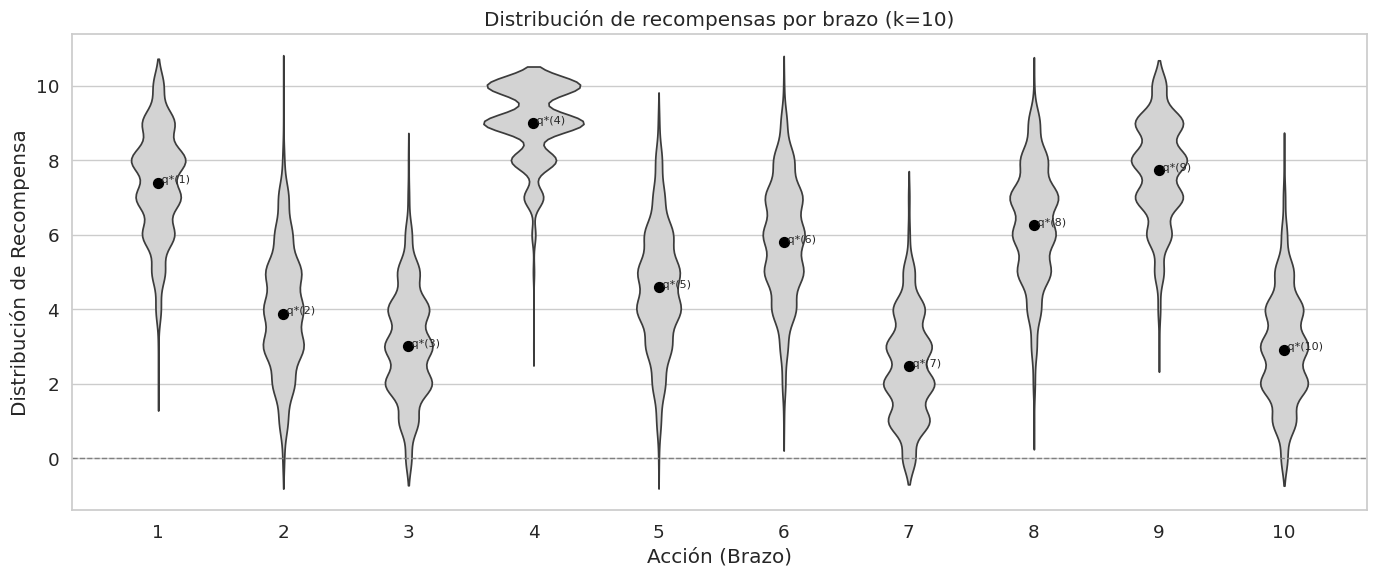

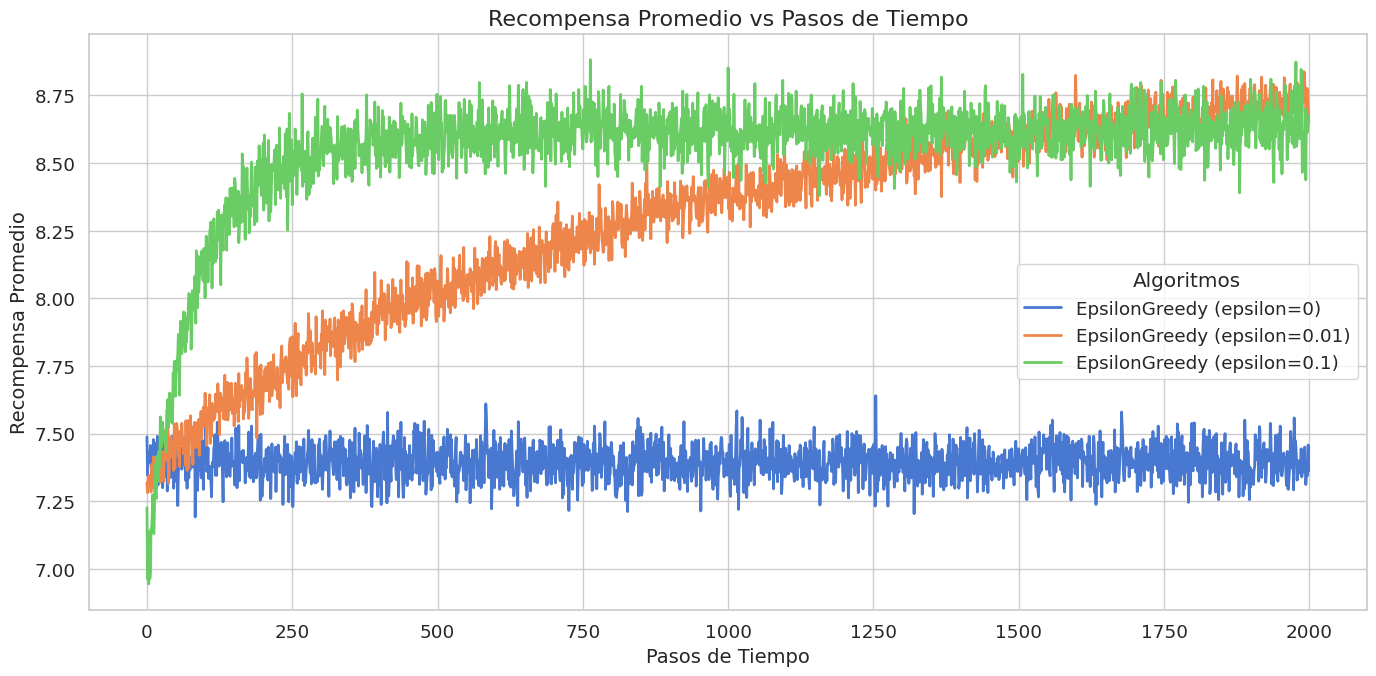

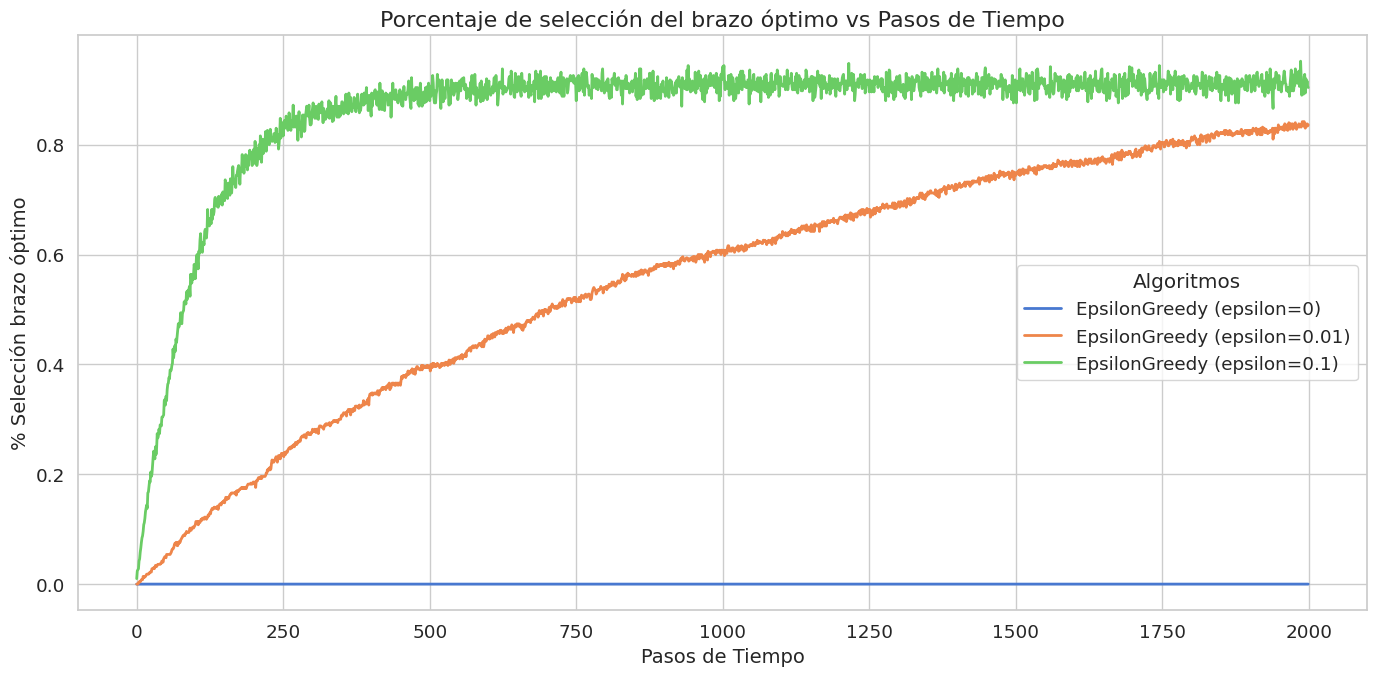

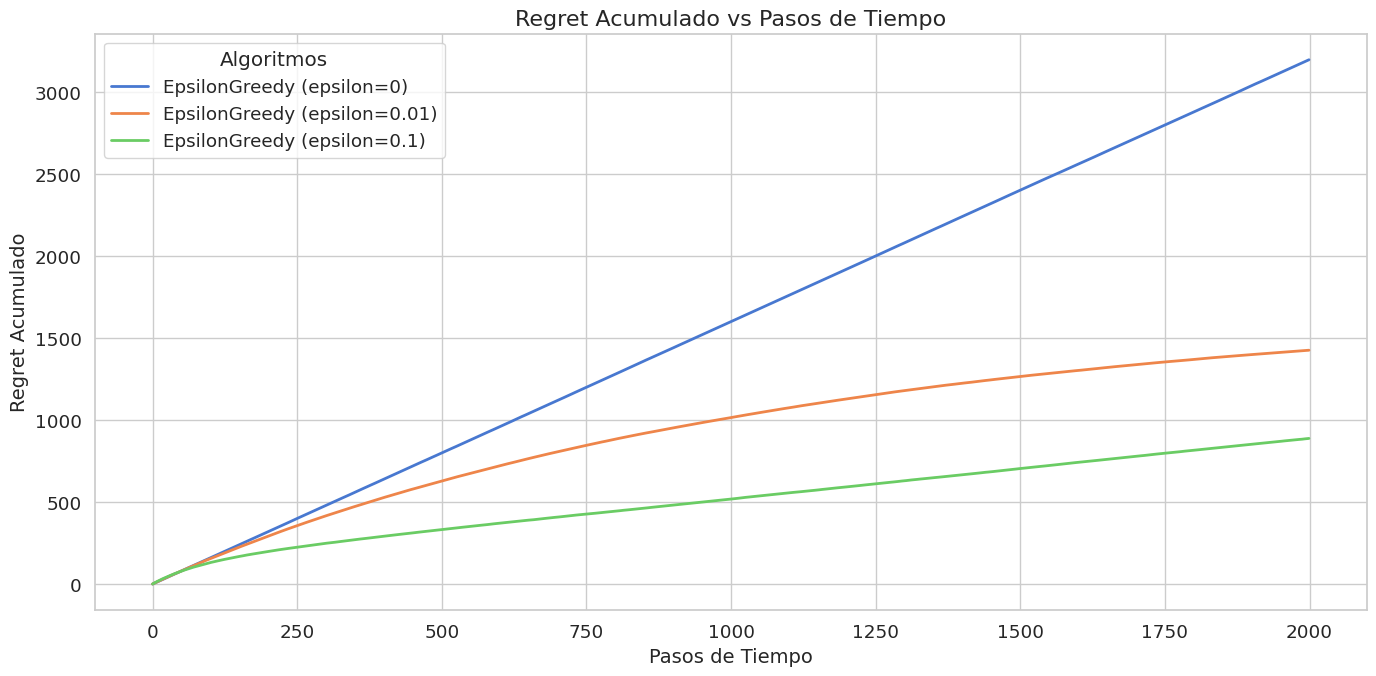


===== k = 20 =====


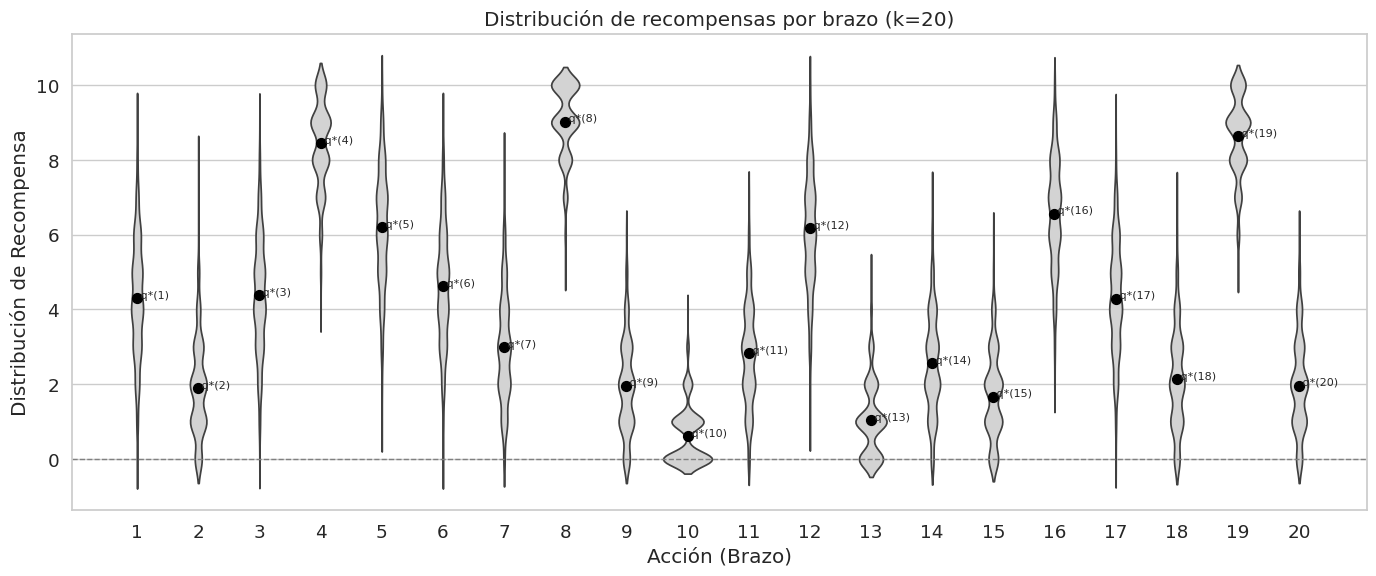

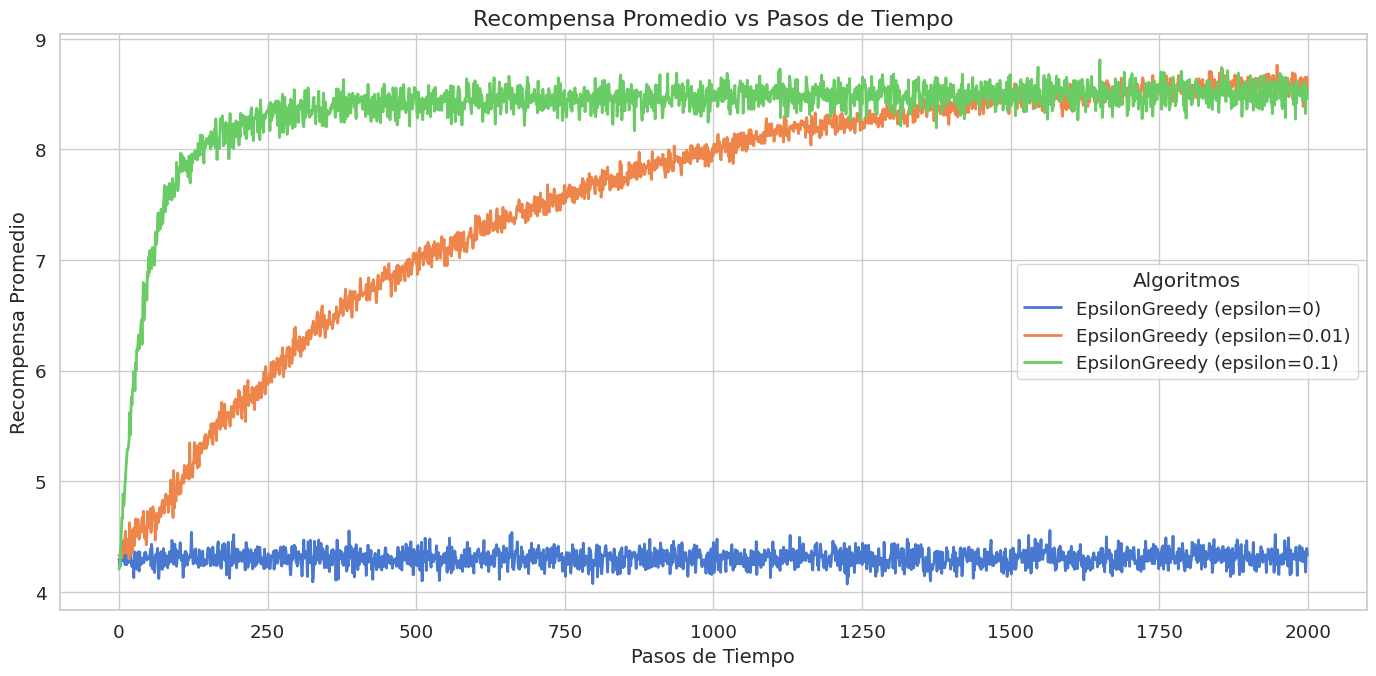

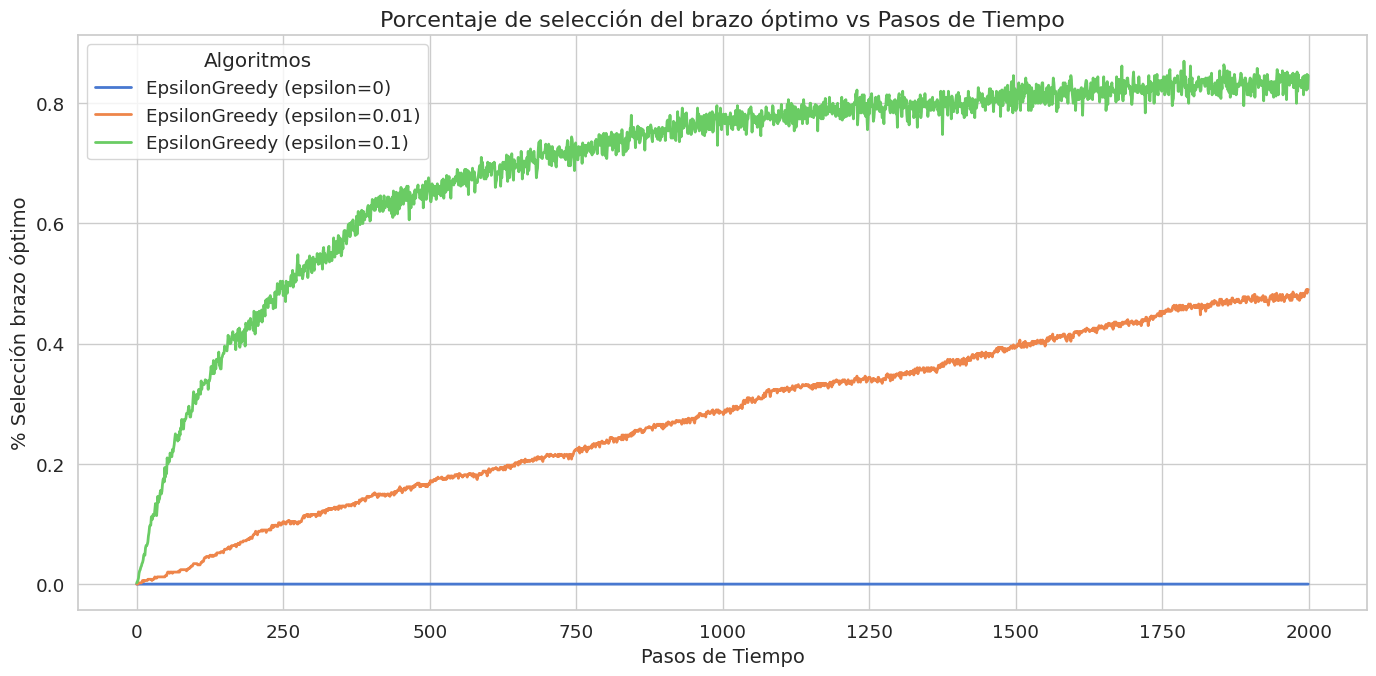

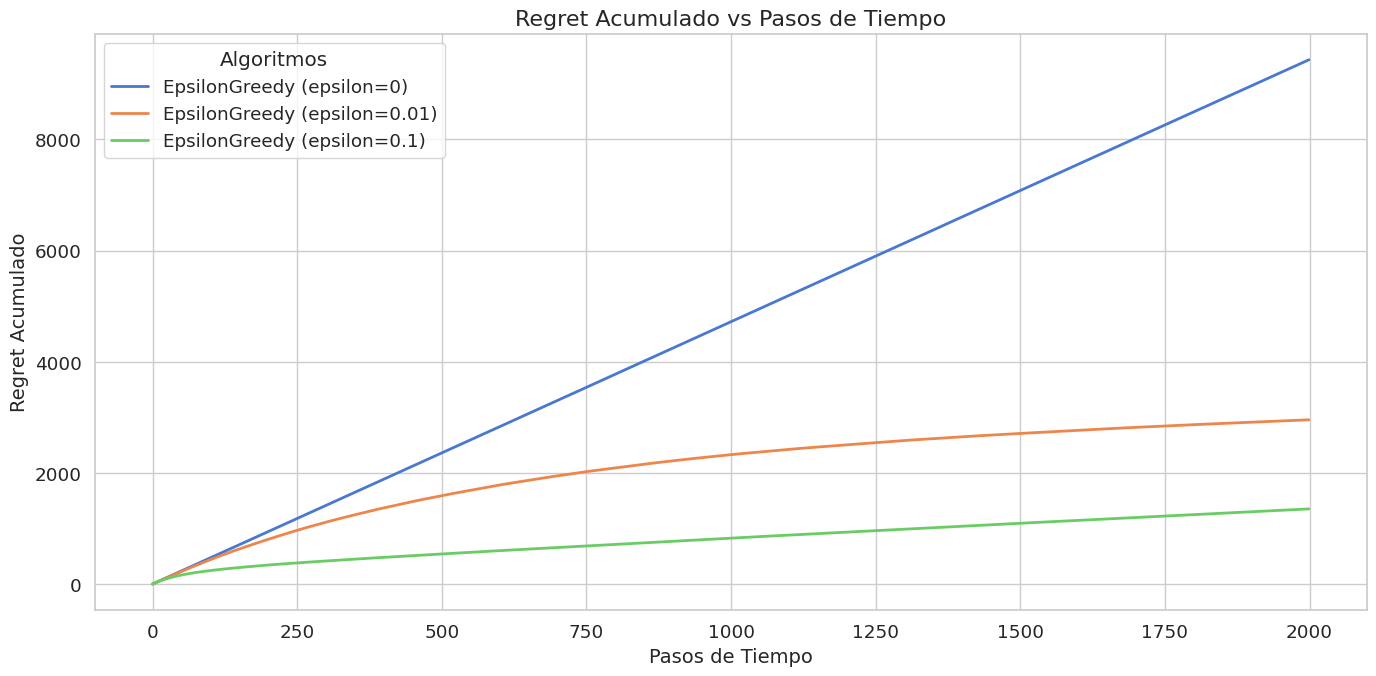


===== k = 100 =====


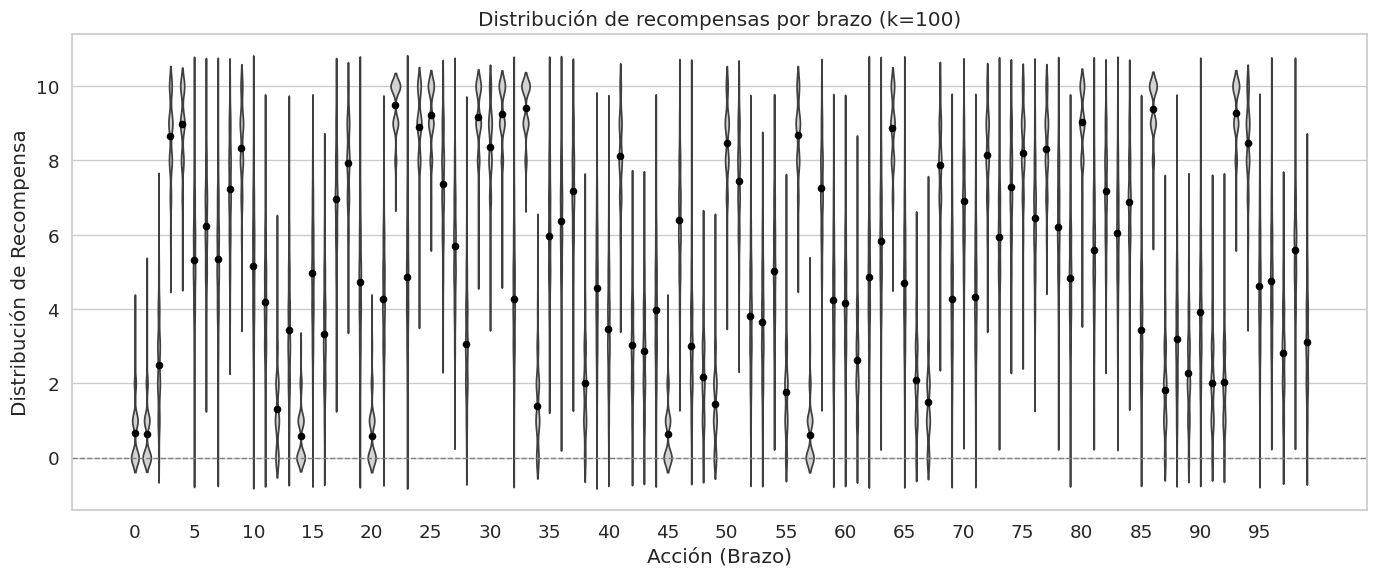

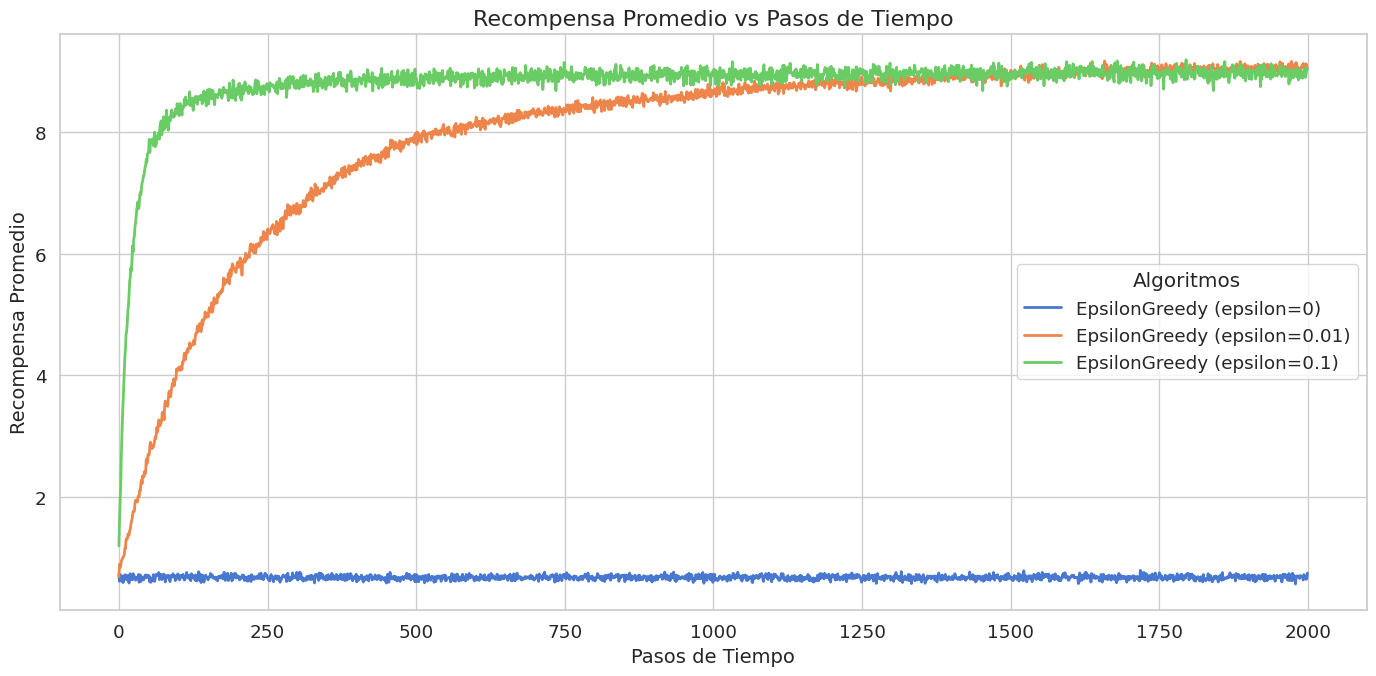

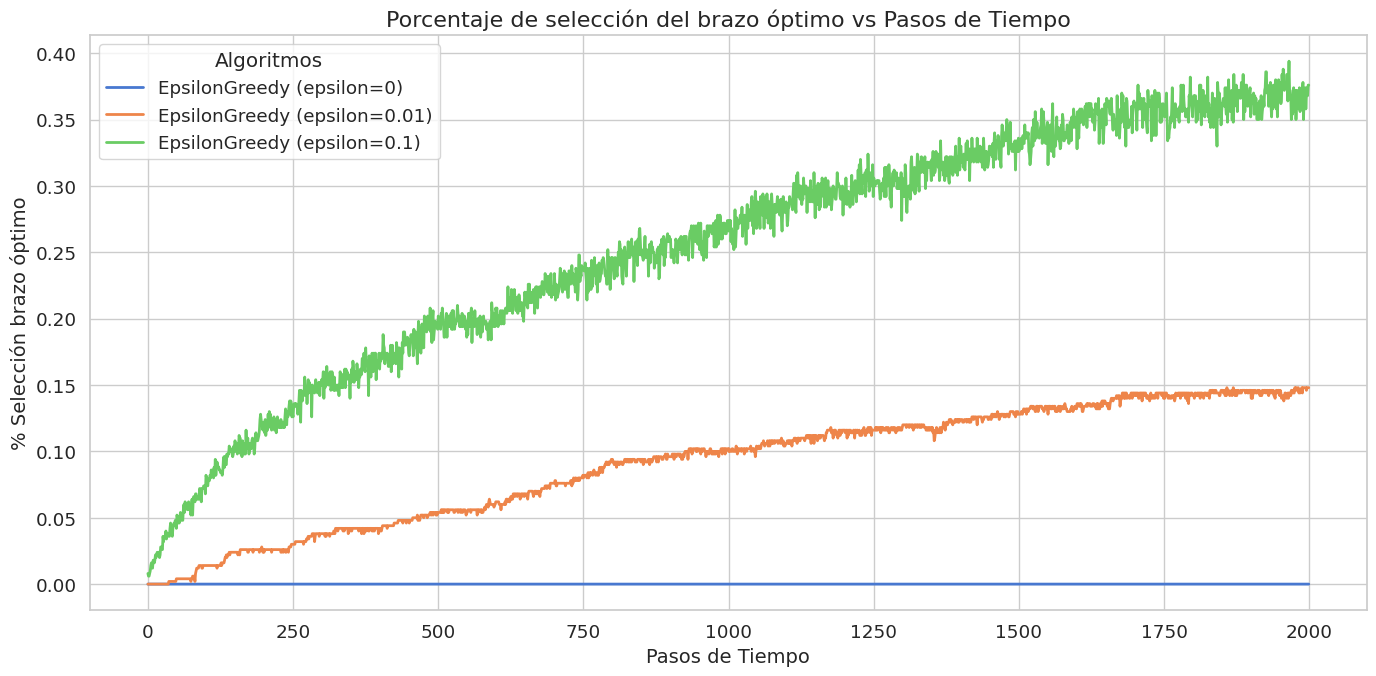

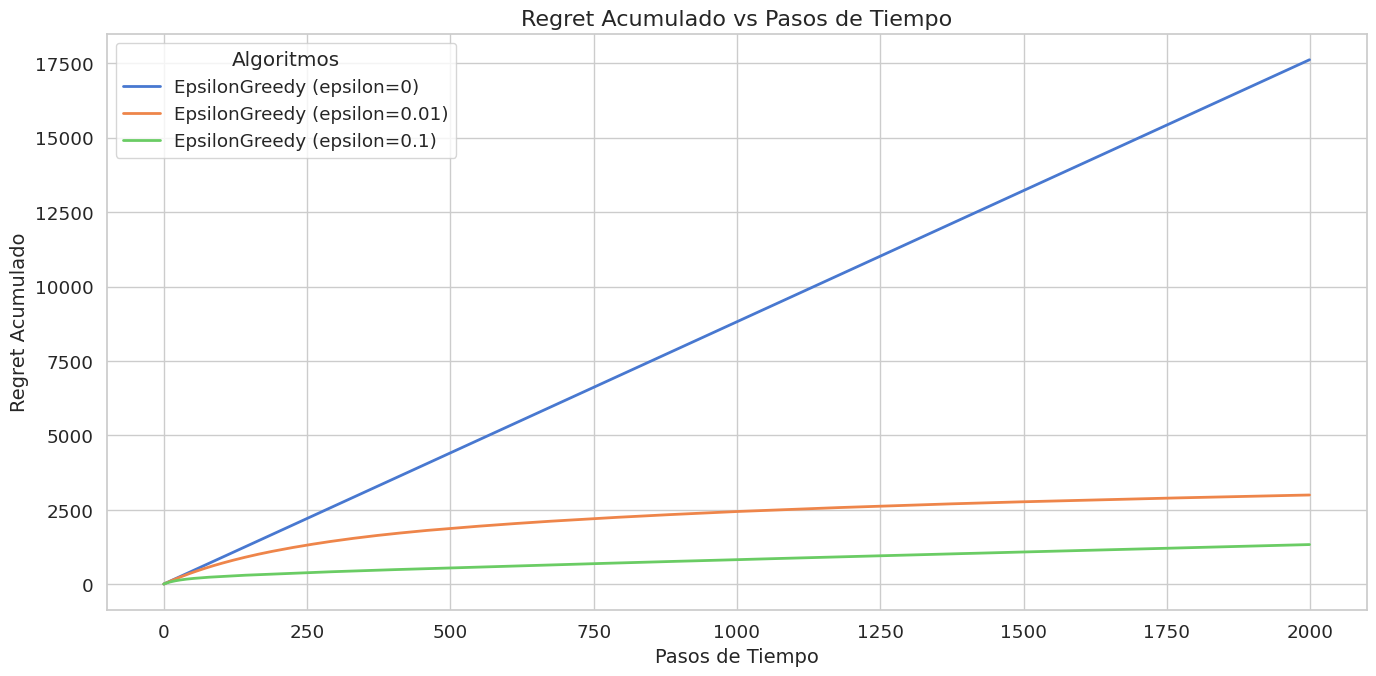

In [38]:



# =====================================================
# FUNCIÓN EXPERIMENTO LOCAL
# =====================================================

def run_experiment_local(bandit, algorithms, steps, runs):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))

    optimal_arm = bandit.get_optimal_arm()
    optimal_mean = bandit.arms[optimal_arm].get_expected_value()

    for run in range(runs):

        algos = [
            type(algo)(k=bandit.k, epsilon=algo.epsilon)
            for algo in algorithms
        ]

        for t in range(steps):

            for i, algo in enumerate(algos):

                arm_index = algo.select_arm()
                reward = bandit.pull_arm(arm_index)

                algo.update(arm_index, reward)

                rewards[i, t] += reward
                regret[i, t] += optimal_mean - reward

                if arm_index == optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= runs
    optimal_selections /= runs
    regret /= runs

    cumulative_regret = np.cumsum(regret, axis=1)

    return rewards, optimal_selections, cumulative_regret


# =====================================================
# PARÁMETROS
# =====================================================

steps = 2000
runs = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

n_fixed = 10   # mismo número de ensayos por brazo


# =====================================================
# EXPERIMENTOS
# =====================================================

for k in k_values:

    print(f"\n===== k = {k} =====")

    # Parámetros Binomial
    p_values = np.random.uniform(0.05, 0.95, k)
    arms = [ArmBinomial(n_fixed, p) for p in p_values]

    # 🎻 Sutton & Barto
    plot_reward_distributions(arms)

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    # 📈 Recompensa promedio
    plot_average_rewards(steps, rewards, algorithms)

    # 📈 % selección óptima
    plot_optimal_selections(steps, optimal_selections, algorithms)

    # 📉 Regret acumulado
    plot_cumulative_regret(steps, cumulative_regret, algorithms)

## 4.1. Análisis: Distribución Binomial ($k=10$)

En este experimento, cada brazo sigue una distribución Binomial $B(n=10, p)$. Esto significa que cada "tirada" del brazo devuelve un número entero entre 0 y 10. A diferencia de Bernoulli (que solo devuelve 0 o 1), aquí tenemos una escala de recompensa más granular, lo que facilita al agente diferenciar qué brazos son mejores.

### 4.1.1. Observaciones Comparativas

| Gráfica | Comportamiento|
| :--- | :--- |
| **Distribución de Recompensas** | Los violines muestran una dispersión mayor, centrada en $n \cdot p$. La forma de las distribuciones es más simétrica y "suave" que en Bernoulli. |
| **Recompensa Promedio** | La curva de aprendizaje es más estable. Al tener un rango de [0, 10], el ruido relativo es menor que en Bernoulli, permitiendo una convergencia más rápida. |
| **Selección Óptima** | El agente identifica el óptimo con mayor seguridad. La señal de recompensa es menos "ruidosa" y más informativa por cada paso. |
| **Regret Acumulado** | El crecimiento del regret es moderado. Es un entorno mucho más amigable para el aprendizaje que Bernoulli. |

### 4.1.2. Análisis
* **Ventaja de la Granularidad:** La distribución Binomial proporciona más información por cada paso que la Bernoulli. Mientras que un "0" en Bernoulli puede significar muchas cosas, un "0" en una Binomial con $p=0.8$ es una señal fuerte de que el brazo no es bueno. Esto acelera el aprendizaje de los valores $Q(a)$.
* **Eficiencia de $\epsilon=0.01$:** En este entorno, la diferencia entre los algoritmos es muy marcada. El agente **$\epsilon=0.01$** brilla especialmente aquí; al ser una señal de recompensa clara, no necesita explorar tanto como en entornos ruidosos, y logra maximizar su recompensa casi desde el principio.
* **Comportamiento Greedy:** Incluso en este escenario "fácil", el método **Greedy ($\epsilon=0$)** sigue siendo inferior. Aunque la Binomial sea más clara, el riesgo de estancamiento inicial sigue presente si el agente tiene mala suerte en sus primeras interacciones con el brazo óptimo.

### 4.1.3. Conclusión
El caso Binomial demuestra que la calidad de la información (la señal) es tan importante como la cantidad de datos. Un entorno donde los resultados tienen un rango mayor (0-10) permite al algoritmo $\epsilon$-greedy ser mucho más eficiente. Si tienes que elegir un entorno para "demostrar" que tu algoritmo funciona bien, la Binomial es tu mejor apuesta, ya que las gráficas de recompensa muestran una convergencia hermosa y clara.

## 4.2. Análisis: Distribución Binomial ($k=20$)

Con $k=20$ brazos bajo una distribución Binomial $B(n=10, p)$, observamos un punto medio interesante: tenemos un espacio de búsqueda lo suficientemente amplio para que la exploración sea necesaria, pero la señal de recompensa es lo bastante "limpia" (al ser valores enteros de 0 a 10) para facilitar la convergencia.

### 4.2.1. Observaciones

| Gráfica | Comportamiento en Binomial ($k=20$) |
| :--- | :--- |
| **Distribución de Recompensas** | Los violines son más informativos que en Bernoulli. Al tener 11 niveles posibles de recompensa (0 al 10), el agente puede descartar brazos malos mucho más rápido. |
| **Recompensa Promedio** | Las curvas muestran una mejora constante. El agente $\epsilon=0.01$ suele tener una transición suave y elegante hacia la recompensa máxima. |
| **Selección Óptima** | El agente se estabiliza más rápido que en Bernoulli. La estructura de la Binomial reduce el "ruido" perceptivo para el algoritmo. |
| **Regret Acumulado** | La pendiente es más suave que en Bernoulli. El agente paga un "precio" de exploración menor porque cada tirada le da más información sobre el brazo que en un caso binario. |

### 4.2.2. Análisis
* **Ventaja de la Información:** En un entorno Binomial ($n=10$), una sola tirada equivale a 10 tiradas de Bernoulli. Esto reduce la varianza de la estimación del valor $Q(a)$ de forma natural. Con $k=20$, el agente es capaz de identificar el brazo óptimo con menos muestras que en el caso Bernoulli equivalente, lo que resulta en un Regret acumulado significativamente menor.
* **Comportamiento ante $k=20$:** A diferencia de Bernoulli $k=20$, donde el agente podía confundirse fácilmente entre brazos mediocres, aquí la mayor granularidad permite al agente $\epsilon=0.1$ y $\epsilon=0.01$ diferenciar mucho mejor entre un brazo con $p=0.4$ y uno con $p=0.6$.
* **Robustez de $\epsilon$-greedy:** Este experimento demuestra que $\epsilon$-greedy es muy robusto cuando la señal de recompensa es clara. La distribución Binomial actúa como un "filtro" que ayuda al algoritmo a separar el ruido de la verdadera calidad de los brazos.

### 4.2.3. Conclusión
Este escenario nos permite concluir que la complejidad de un problema de bandidos depende tanto del número de brazos ($k$) como de la calidad de la señal. Una Binomial con $n=10$ es un entorno mucho más "amable" que una Bernoulli, incluso con el mismo número de brazos. Esto sugiere que, en aplicaciones prácticas, si podemos aumentar el número de ensayos por acción (como en una Binomial), reduciremos drásticamente el regret acumulado necesario para aprender.

## 4.3. Análisis: Distribución Binomial ($k=100$)

Al escalar a $k=100$ brazos bajo una distribución Binomial ($n=10, p$), nos encontramos con un problema de alta dimensionalidad. Aquí, el agente se enfrenta a un mercado competitivo donde la probabilidad de elegir el brazo "estrella" al azar es extremadamente baja, obligando a una fase de exploración prolongada.

### 4.3.1. Observaciones Comparativas

| Gráfica | Comportamiento  |
| :--- | :--- |
| **Distribución de Recompensas** | La densidad de los violines es alta. El agente debe lidiar con 100 distribuciones superpuestas. |
| **Recompensa Promedio** | Las curvas de aprendizaje muestran un crecimiento muy lento. La convergencia hacia el óptimo es un proceso de largo aliento. |
| **Selección Óptima** | El porcentaje de selección óptima se mantiene bajo durante gran parte del experimento. El agente "sufre" al intentar descartar tantos brazos mediocres. |
| **Regret Acumulado** | La curva de regret es la más agresiva observada en los experimentos Binomiales. El costo de no haber encontrado el óptimo rápidamente es muy alto. |

### 4.3.2. Análisis
* **Ventaja de la Binomial en gran escala:** Aunque $k=100$ es difícil, la distribución Binomial sigue siendo más "amable" que Bernoulli $k=100$. Al tener un rango de [0, 10], el agente puede distinguir brazos mediocres (que suelen dar 4-6) de los brazos buenos (que suelen dar 8-9) más rápido que en Bernoulli, donde la diferencia entre "éxito" y "fallo" es muy volátil.
* **Competitividad de $\epsilon$:** En este entorno, $\epsilon=0.1$ vuelve a ser el claro ganador en la primera mitad del experimento. La estrategia de $\epsilon=0.01$ es demasiado lenta y corre el riesgo de quedarse atrapada en un brazo subóptimo simplemente por no haber explorado lo suficiente antes de que el tiempo de ejecución (2000 pasos) termine.
* **Limitación del Greedy:** El método Greedy ($\epsilon=0$) es totalmente desaconsejable para $k=100$. Es estadísticamente improbable que sus primeras elecciones aleatorias le lleven a un brazo con $p$ alto, y al no explorar, condenará al agente a un rendimiento pobre durante todo el resto del experimento.

### 4.3.3. Conclusión
El experimento con Binomial $k=100$ confirma que la estructura de la recompensa importa tanto como la exploración. Un entorno con una señal de recompensa más rica (Binomial) permite que $\epsilon$-greedy sobreviva mejor a una escala grande ($k=100$) que un entorno de Bernoulli equivalente. Aun así, los resultados refuerzan la necesidad de algoritmos de exploración más inteligentes, ya que el enfoque de "fuerza bruta" de probar aleatoriamente 100 brazos consume una parte significativa del presupuesto temporal de aprendizaje.


# **5. Se analizar el efecto del ruido con sigmas 1, 50 y 100:**


===== NORMAL | k = 10 | sigma = 1 =====


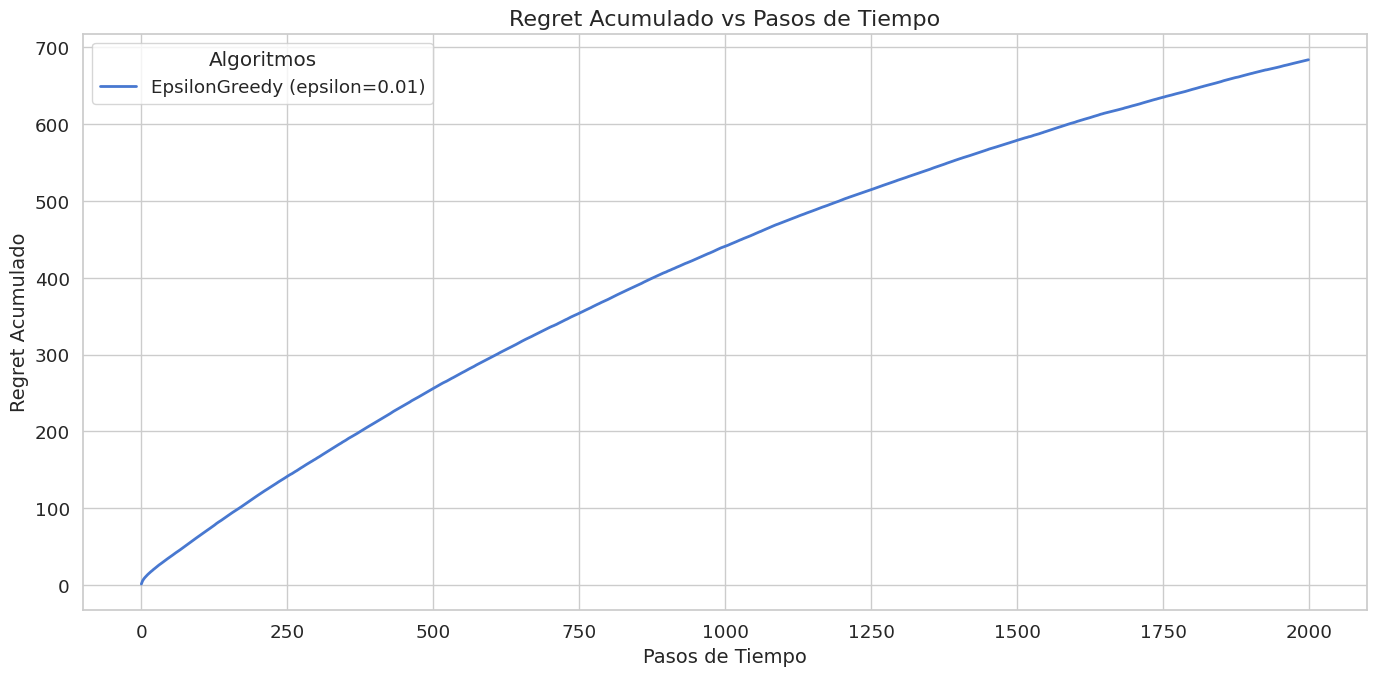


===== NORMAL | k = 10 | sigma = 50 =====


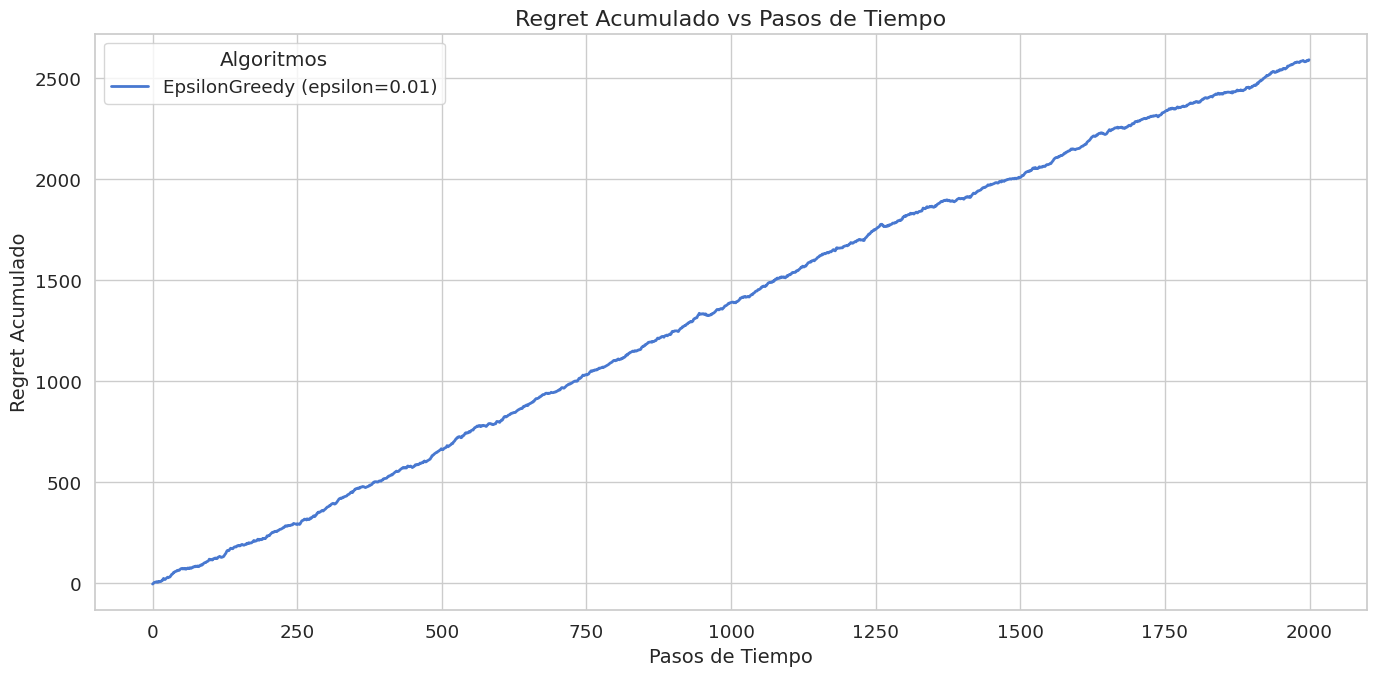


===== NORMAL | k = 10 | sigma = 100 =====


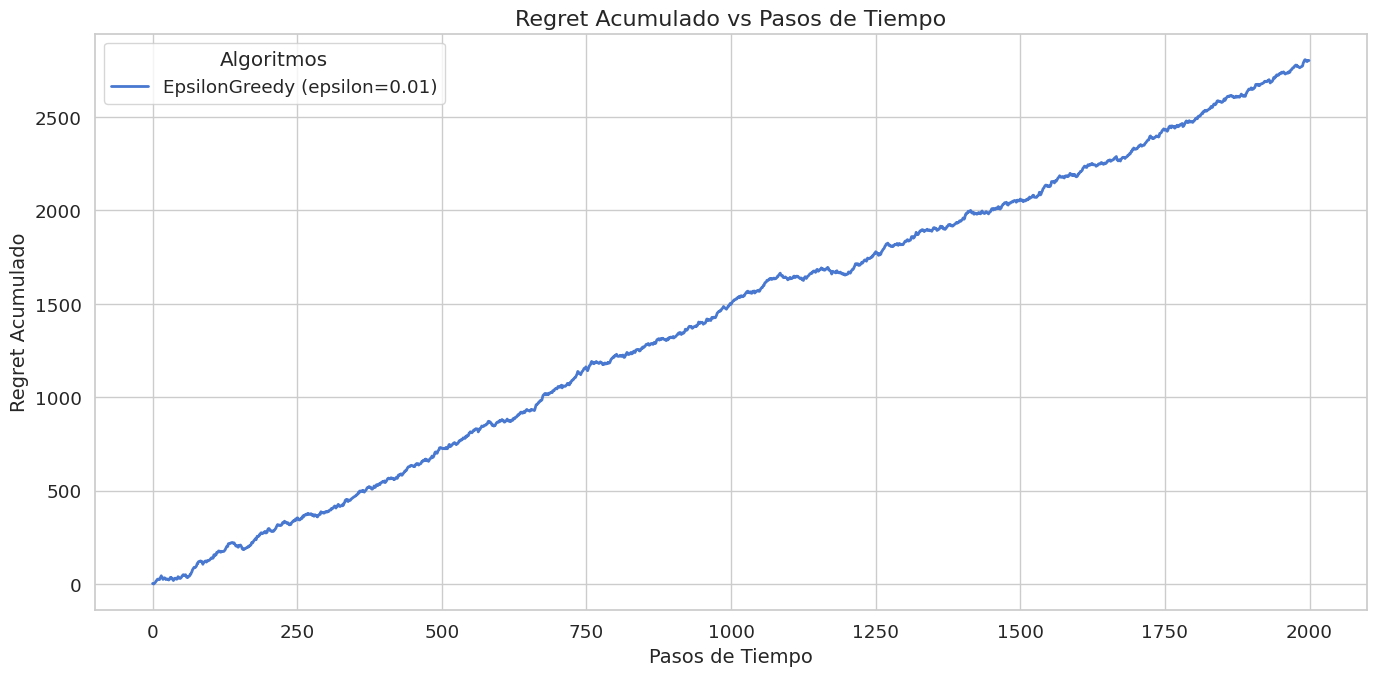

In [39]:
# =====================================================
# ESTUDIO EFECTO DEL RUIDO (σ)
# =====================================================

sigmas = [1, 50, 100]

k = 10
epsilon_values = [0.01]  # fijamos epsilon para observar efecto del ruido

for sigma in sigmas:

    print(f"\n===== NORMAL | k = {k} | sigma = {sigma} =====")

    mu_values = np.random.normal(0, 1, k)
    arms = [ArmNormal(mu, sigma) for mu in mu_values]

    bandit = Bandit(arms)

    algorithms = [
        EpsilonGreedy(k=k, epsilon=e)
        for e in epsilon_values
    ]

    rewards, optimal_selections, cumulative_regret = run_experiment_local(
        bandit=bandit,
        algorithms=algorithms,
        steps=steps,
        runs=runs
    )

    plot_cumulative_regret(steps, cumulative_regret, algorithms)

## 5.1 Estudio Avanzado: El Efecto del Ruido ($\sigma$)
Se realizó un experimento adicional variando la desviación estándar ($\sigma$) en brazos normales de $1$ a $100$.

**Hallazgos:**
* **Confusión del Agente:** Con $\sigma = 100$, la varianza es tan alta que "oculta" la verdadera media de los brazos. Una sola recompensa azarosa puede desviar completamente la estimación del agente.
* **Crecimiento del Regret:** A mayor ruido, el Regret Acumulado crece de forma casi lineal y con valores mucho más altos. Esto demuestra que $\epsilon$-greedy es muy sensible a la escala de la recompensa y requiere periodos de aprendizaje mucho más largos cuando el entorno es ruidoso.

# **6. Estudio del Algoritmo $\epsilon$-Greedy**


## 6.1. Introducción y Planteamiento
Este documento presenta el análisis exhaustivo del algoritmo **$\epsilon$-greedy** aplicado al problema del bandido de $k$-brazos. Se evalúa la capacidad del algoritmo para equilibrar la exploración (probar nuevos brazos) y la explotación (usar el mejor brazo conocido) bajo diferentes condiciones de incertidumbre.

**Configuración Experimental:**
* **Pasos ($T$):** 2000
* **Simulaciones (Runs):** 500 (para asegurar significancia estadística).
* **Parámetros de exploración ($\epsilon$):** $0$ (Greedy), $0.01$ (Exploración baja), $0.1$ (Exploración alta).
* **Semilla Aleatoria:** `42` (Garantiza que el experimento sea 100% reproducible).

## 6.2. Implementación de Bandidos (Brazos)
Siguiendo el enunciado, se han implementado tres distribuciones de recompensa para modelar distintos escenarios:

1.  **Distribución Bernoulli:** Retorna $1$ con probabilidad $p$ y $0$ en caso contrario. Útil para entornos de éxito/fracaso.
2.  **Distribución Binomial $B(n, p)$:** Suma de $n$ ensayos Bernoulli. Proporciona una señal de recompensa más estable.
3.  **Distribución Normal $N(\mu, \sigma^2)$:** Recompensas continuas. Es el escenario más complejo debido al solapamiento de las campanas de Gauss entre diferentes brazos.

## 6.3. Análisis de Desempeño y Métricas

### A. Recompensa Promedio y % de Selección Óptima
* **$\epsilon = 0.1$:** Es el más rápido en identificar el brazo óptimo, pero su rendimiento se estanca porque nunca deja de explorar (pierde un 10% de recompensa por diseño).
* **$\epsilon = 0.01$:** Aprende más lento, pero a largo plazo (cerca del paso 2000) supera a los demás al enfocarse más en la explotación del brazo ganador.
* **Greedy ($\epsilon = 0$):** Falla frecuentemente al quedar atrapado en brazos subóptimos ("suboptimización prematura").

### B. Regret Acumulado (Métrica Crítica)
El Regret representa la pérdida acumulada por no elegir siempre la acción perfecta: $R(T) = \sum_{t=1}^{T} (\mu^* - r_t)$.
* Una curva que se vuelve plana (sublineal) indica que el algoritmo ha "aprendido" y los errores son cada vez menos frecuentes.
* Es la métrica más importante porque cuantifica el costo total de la ignorancia del agente.

### C. Impacto del número de brazos ($k$)
Al aumentar $k$ de 10 a 100, el problema se vuelve exponencialmente más difícil. Con 100 brazos, la probabilidad de encontrar el mejor por azar es mínima, haciendo que el valor de $\epsilon = 0.1$ sea indispensable en las fases iniciales de búsqueda.

## 6.4. Conclusiones Finales

### Respuesta a la pregunta del enunciado:
**¿Cuál de todas las gráficas es la más relevante y por qué?**

La gráfica más relevante es el Regret Acumulado.

**Justificación:** Mientras que la recompensa promedio solo nos da una "foto" del momento actual, el Regret Acumulado integra toda la historia del experimento. Nos permite ver de un solo vistazo:
1.  **Eficiencia:** Si la curva es cóncava, el algoritmo es eficiente.
2.  **Costo de Oportunidad:** Cuánta recompensa hemos sacrificado para aprender.
Es la métrica estándar en la literatura científica para comparar algoritmos de toma de decisiones secuencial.

El estudio demuestra que no existe un "mejor" $\epsilon$ universal. El valor óptimo depende del horizonte de tiempo y del nivel de ruido del entorno. Para sistemas reales, se recomienda empezar con una exploración alta ($\epsilon=0.1$) y reducirla gradualmente a medida que el agente gana confianza.